# Threat Index design
We are going to be using an application-specific impact. Since our project surrounds IM sports, we will focus on outdoor sports safety, specifically at the IM. Our target audience will be campus officials that cancel campus activities. Our scale will be 0-100, where 0 would be no risk, and 100 would be an automatic cancellation. 

### Variables/reasoning:
1. Temperature - temperatures too cold or too hot become a legitimate threat to human health. 
2. Precip - who wants to play outside when it's pouring rain?
3. Wind gust - comes from the famous video of the guy getting hit by a porta-potty. Overall point is that the potential for large objects to be tossed around is possible with strong wind gusts, and it becomes a problem if someone gets hit by said object.
4. Wet bulb globe temp (derived value) - combining some variables, along with other variables like RH, sun angle, and cloud cover. 
5. Overall threat index - putting together all of the variables

These variables make sense because they all can cause bodily harm to people when they achieve a certain intensity. 


### How the Formula Works
Our index operates on a 0-100 scale, where 0 represents "Perfect Play Conditions" and 100 represents an "Automatic Cancellation." The formula is designed to be non-linear and impact-based.

It makes sense because it doesn't just average the weather; it looks for "deal-breakers." For example, if the Wind Gust exceeds a certain safety threshold or the WBGT enters the "Black Flag" category, the index is designed to spike toward 100 regardless of how "nice" the other variables might be. This reflects the reality of campus safety: one dangerous variable is enough to warrant a cancellation.

### Variable Weight
In our Python implementation, the variables are combined using a weighted hierarchy that prioritizes thermal stress:

Primary Weight (70%): The Wet Bulb component. This is the "heavy lifter" of the formula, combining air temperature and humidity to measure evaporative cooling potential.

Secondary Weight (20%): The Globe component. This integrates solar radiation (from ECMWF ssrd data) and wind to simulate the radiant heat load on an athlete standing in the middle of an open IM field.

Tertiary Weight (10%): The Dry Bulb component. This provides the ambient air temperature baseline to keep the index grounded in standard meteorological observations.

Safety Overrides: Precipitation and Wind Gusts act as "multiplier" or "threshold" gates. If precipitation exceeds a specific rate (mm/hr) or gusts exceed safety limits, these factors can override the thermal index to force a high-threat score.

### Usefulness to an Audience
This index is built specifically for Campus Officials who manage IM sports and outdoor activities. It is useful for three key reasons:

Standardized Safety: It replaces subjective "gut feelings" with an objective, data-driven score. This ensures consistency across different sports and administrators.

Advanced Planning: By using ECMWF forecast data, officials can see a 100-point threat spike coming hours or days in advance, allowing them to notify students of cancellations before they arrive at the fields.

Hyper-Local Focus: Most weather apps provide "city-level" data. Our index uses coordinates specific to the State College IM fields, ensuring the "Threat Score" reflects the actual conditions where the students are playing.

In [1]:
#import all packages
from herbie import FastHerbie
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os

In [2]:
#call in the variables
ds_a = xr.open_dataset("Marecmwf_20260323Mar.nc")
ds_b = xr.open_dataset("10fgMarecmwf_20260323Mar.nc")
ds2 = xr.merge([ds_a, ds_b], compat = 'override')
ds2

sh: 1: getfattr: not found
sh: 1: getfattr: not found


<xarray.Dataset> Size: 80kB
Dimensions:            (valid_time: 15, latitude: 11, longitude: 24)
Coordinates:
  * valid_time         (valid_time) datetime64[ns] 120B 2026-03-23 ... 2026-0...
  * latitude           (latitude) float64 88B 42.25 42.0 41.75 ... 40.0 39.75
  * longitude          (longitude) float64 192B -80.5 -80.25 ... -75.0 -74.75
    time               datetime64[ns] 8B ...
    step               (valid_time) timedelta64[ns] 120B ...
    surface            float64 8B ...
    heightAboveGround  float64 8B ...
Data variables:
    tp                 (valid_time, latitude, longitude) float32 16kB ...
    sf                 (valid_time, latitude, longitude) float32 16kB ...
    t2m                (valid_time, latitude, longitude) float32 16kB ...
    d2m                (valid_time, latitude, longitude) float32 16kB ...
    fg10               (valid_time, latitude, longitude) float32 16kB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-04-08T17:28 GRIB to CDM+CF via cfgrib-0.9.1...

In [3]:
#useful variables
temp=ds2['t2m']
snow=ds2['sf']
dew=ds2['d2m']
wind_gust=ds2['fg10']
precip=ds2['tp']


In [4]:
#unit conversions
temp_f = (temp - 273.15) * 9/5 + 32
dew_f = (dew - 273.15) * 9/5 + 32
precip_mm = precip * 1000
wind_mph = wind_gust * 2.237
snow_mm = snow * 1000
times = ds2['valid_time'].values

#Relavtive Humidity Def: 
def calc_rh(T, Td):
    return 100 * np.exp((17.625 * Td)/(243.04 + Td)) / np.exp((17.625 * T)/(243.04 + T))

#Wet Bulb Def: 
def wet_bulb_temp(T, RH):
    return T * np.arctan(0.151977 * (RH + 8.313659)**0.5) + \
           np.arctan(T + RH) - np.arctan(RH - 1.676331) + \
           0.00391838 * RH**1.5 * np.arctan(0.023101 * RH) - 4.686035

def wbgt_calc(T, Tw, Tg):
    # ALL inputs in Celsius
    return (0.7 * Tw) + (0.2 * Tg) + (0.1 * T)

In [5]:
# Store results
precip_risk = []
wind_risk = []
wbgt_risk = []
field_risk = []

times = ds2['valid_time'].values
#getting the valid time information
for t in range(len(times)):

    T = temp_f.isel(valid_time=t).values
    Td = dew_f.isel(valid_time=t).values
    P = precip_mm.isel(valid_time=t).values
    S = snow_mm.isel(valid_time=t).values
    W = wind_mph.isel(valid_time=t).values

    # conversions
    W_ms = W * 0.44704
    T_c = (T - 32) * 5/9
    Td_c = (Td - 32) * 5/9

    # ==============================
    # HUMIDITY + WET BULB
    # ==============================
    RH = calc_rh(T_c, Td_c)
    RH = np.clip(RH, 0, 100)

    Tw = wet_bulb_temp(T_c, RH)

    # ==============================
    # Tg (STABLE EMPIRICAL MODEL)
    # ==============================
    Tg = T_c + 1.5 + (0.15 * T_c) - (0.25 * W_ms)

    # ==============================
    # WBGT (FIXED)
    # ==============================
    WBGT = (wbgt_calc(T_c, Tw, Tg)*1.8)+32

In [6]:
temp_f = (ds2['t2m'].values - 273.15)*(9/5) + 32
snow= (ds2['sf'].values)*10 #10 inches of snow typically equals about 1 inch of water
wind_gust=(ds2['fg10'].values)*2.2369 #into mph
precip=(ds2['tp'].values)*39.37
dew_f=(ds2['d2m'].values - 273.15)*(9/5) + 32
lats = ds2['latitude'].values
lons = ds2['longitude'].values


In [7]:
temp_f_2d = temp_f[0, :, :] 
dew_f_2d=dew_f[0,:,:]
precip_2d=precip[1,:,:]
snow_2d=snow[0,:,:]
wind_gust_2d=wind_gust[1,:,:]


In [8]:

WBGT = (wbgt_calc(T_c, Tw, Tg)*1.8)+32

In [33]:
#Calling variables for next run
ds_a = xr.open_dataset("Marecmwf_20260323Mar.nc")
ds_b = xr.open_dataset("10fgMarecmwf_20260323Mar.nc")
ds2 = xr.merge([ds_a, ds_b], compat = 'override')
ds2

sh: 1: getfattr: not found
sh: 1: getfattr: not found


<xarray.Dataset> Size: 80kB
Dimensions:            (valid_time: 15, latitude: 11, longitude: 24)
Coordinates:
  * valid_time         (valid_time) datetime64[ns] 120B 2026-03-23 ... 2026-0...
  * latitude           (latitude) float64 88B 42.25 42.0 41.75 ... 40.0 39.75
  * longitude          (longitude) float64 192B -80.5 -80.25 ... -75.0 -74.75
    time               datetime64[ns] 8B ...
    step               (valid_time) timedelta64[ns] 120B ...
    surface            float64 8B ...
    heightAboveGround  float64 8B ...
Data variables:
    tp                 (valid_time, latitude, longitude) float32 16kB ...
    sf                 (valid_time, latitude, longitude) float32 16kB ...
    t2m                (valid_time, latitude, longitude) float32 16kB ...
    d2m                (valid_time, latitude, longitude) float32 16kB ...
    fg10               (valid_time, latitude, longitude) float32 16kB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-04-08T17:28 GRIB to CDM+CF via cfgrib-0.9.1...

In [34]:

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap, BoundaryNorm

# ==============================
# Lat/Lon
# ==============================
lon = ds2['longitude'].values
lat = ds2['latitude'].values
lon2d, lat2d = np.meshgrid(lon, lat)

# ==============================
# State College Coordinates
# ==============================
sc_lon = -77.8600
sc_lat = 40.7934

# ==============================
# RH FUNCTION
# ==============================
def calc_rh(temp_f, dew_f):
    temp_c = (temp_f - 32) * 5/9
    dew_c  = (dew_f - 32) * 5/9

    es = 6.112 * np.exp((17.67 * temp_c)/(temp_c + 243.5))
    e  = 6.112 * np.exp((17.67 * dew_c)/(dew_c + 243.5))

    rh = (e / es) * 100
    return np.clip(rh, 0, 100)

In [35]:


# ==============================
# COLORMAP
# ==============================
colors = ["#2ECC71", "#F1C40F", "#E67E22", "#E74C3C", "#8E44AD"]
risk_cmap = ListedColormap(colors)
bounds = [0, 0.25, 0.5, 0.75, 0.9, 1.0]
norm = BoundaryNorm(bounds, risk_cmap.N)

# ==============================
# SELECT TIME STEPS
# ==============================
times_idx = [0, 2, 4, 6, 8, 10]
times_actual = ds2.valid_time.values[times_idx]

# ==============================
# STORAGE
# ==============================
PUI_list = []
temp_risk_list = []
wind_risk_list = []
precip_risk_list = []
WBGT_risk_list = []

# ==============================
# LOOP 
# ==============================
for i in times_idx:

    tempf2d = (ds2['t2m'].isel(valid_time=i).values - 273.15)*(9/5)+32
    dewf2d = (ds2['d2m'].isel(valid_time=i).values - 273.15)*(9/5)+32
    windgust2d = ds2['fg10'].isel(valid_time=i).values * 2.2369

    if i > 0:
        accum_precip = (
            ds2['tp'].isel(valid_time=i).values -
            ds2['tp'].isel(valid_time=i-1).values
        ) * 39.37
    else:
        accum_precip = ds2['tp'].isel(valid_time=i).values * 39.37

    RH = calc_rh(tempf2d, dewf2d)
    Tw = wet_bulb_temp(tempf2d, RH)
    WBGT = (wbgt_calc(T_c, Tw, Tg)*1.8)+32

    # --- Temperature Risk ---
    temp_risk = np.zeros_like(tempf2d)
    temp_risk[tempf2d < 40] = (40 - tempf2d[tempf2d < 40]) / 40
    mask = (tempf2d >= 40) & (tempf2d <= 75)
    temp_risk[mask] = 0
    mask = tempf2d > 75
    temp_risk[mask] = (tempf2d[mask] - 75) / 25
    temp_risk = np.clip(temp_risk, 0, 1)

    # --- WBGT Risk ---
    WBGT_risk = np.zeros_like(WBGT)
    WBGT_risk[(WBGT >= 80) & (WBGT < 85)] = 0.25
    WBGT_risk[(WBGT >= 85) & (WBGT < 88)] = 0.5
    WBGT_risk[(WBGT >= 88) & (WBGT < 90)] = 0.75
    WBGT_risk[WBGT >= 90] = 1.0

    # --- Wind Risk ---
    wind_risk = np.zeros_like(windgust2d)
    wind_risk[(windgust2d >= 15) & (windgust2d < 25)] = 0.3
    wind_risk[(windgust2d >= 25) & (windgust2d < 40)] = 0.6
    wind_risk[windgust2d >= 40] = 1.0

    # --- Precip Risk ---
    precip_risk = np.zeros_like(accum_precip)
    precip_risk[(accum_precip >= 0.05) & (accum_precip < 0.25)] = 0.3
    precip_risk[(accum_precip >= 0.25) & (accum_precip < 0.75)] = 0.6
    precip_risk[accum_precip >= 0.75] = 1.0

    temp_risk = np.nan_to_num(temp_risk)
    wind_risk = np.nan_to_num(wind_risk)
    precip_risk = np.nan_to_num(precip_risk)

    PUI = temp_risk + wind_risk + precip_risk + WBGT_risk
    PUI = np.nan_to_num(PUI)

    PUI_list.append(PUI)
    temp_risk_list.append(temp_risk)
    wind_risk_list.append(wind_risk)
    precip_risk_list.append(precip_risk)
    WBGT_risk_list.append(WBGT_risk)

# ==============================
# MAP FORMAT FUNCTION
# ==============================
def format_map(ax):
    ax.set_extent([-80.6, -74.5, 39.5, 42.5])
    ax.add_feature(cfeature.STATES, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)

    # --- State College dot ---
    ax.scatter(
        sc_lon, sc_lat,
        color='red',
        s=80,
        edgecolor='black',
        transform=ccrs.PlateCarree(),
        zorder=10
    )

    ax.text(
        sc_lon + 0.1, sc_lat + 0.1,
        "State College",
        fontsize=9,
        transform=ccrs.PlateCarree()
    )



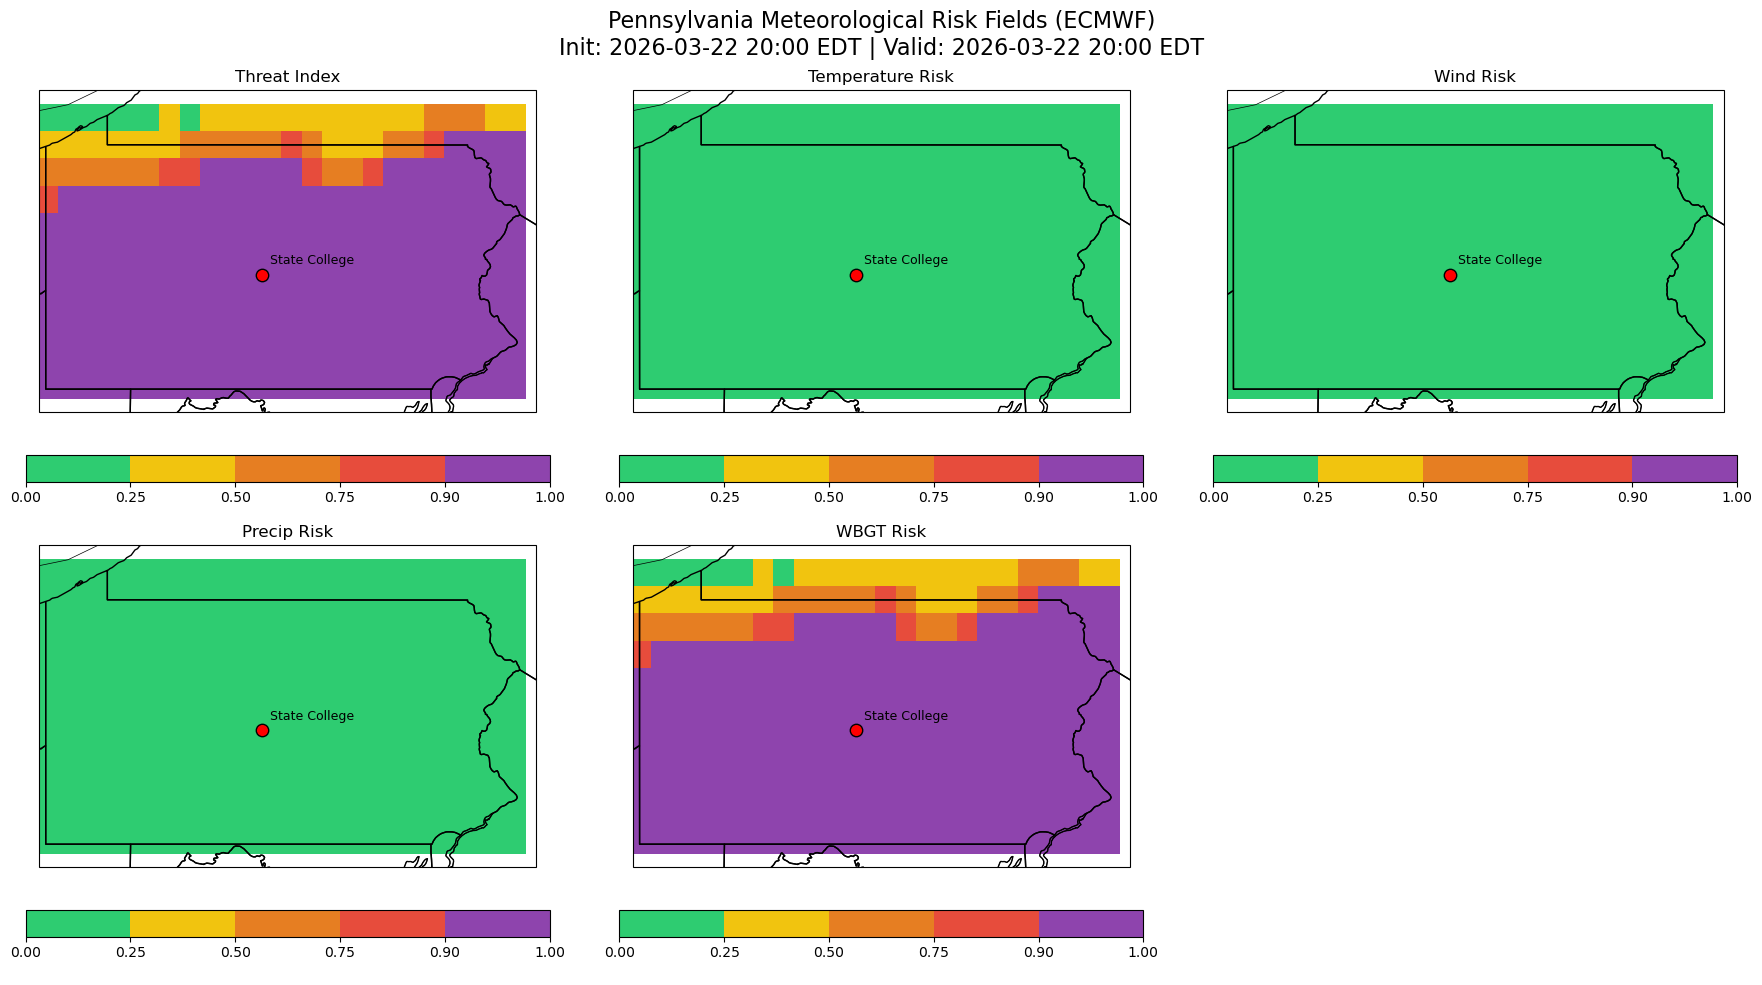

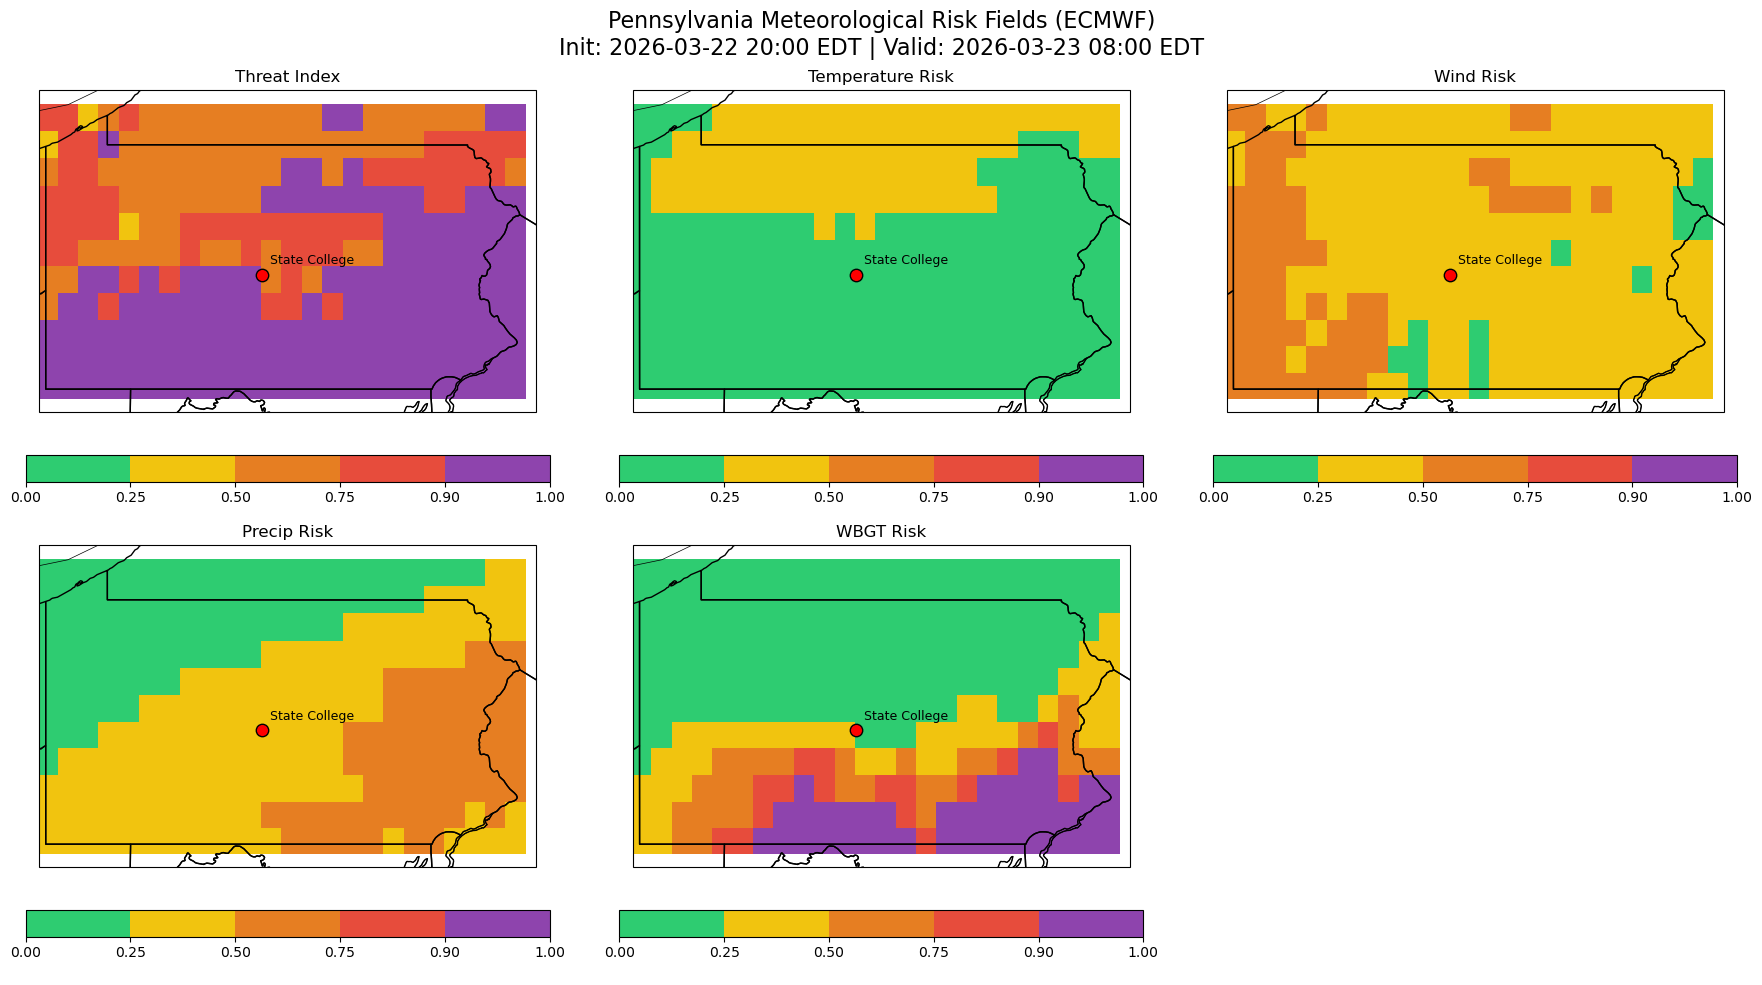

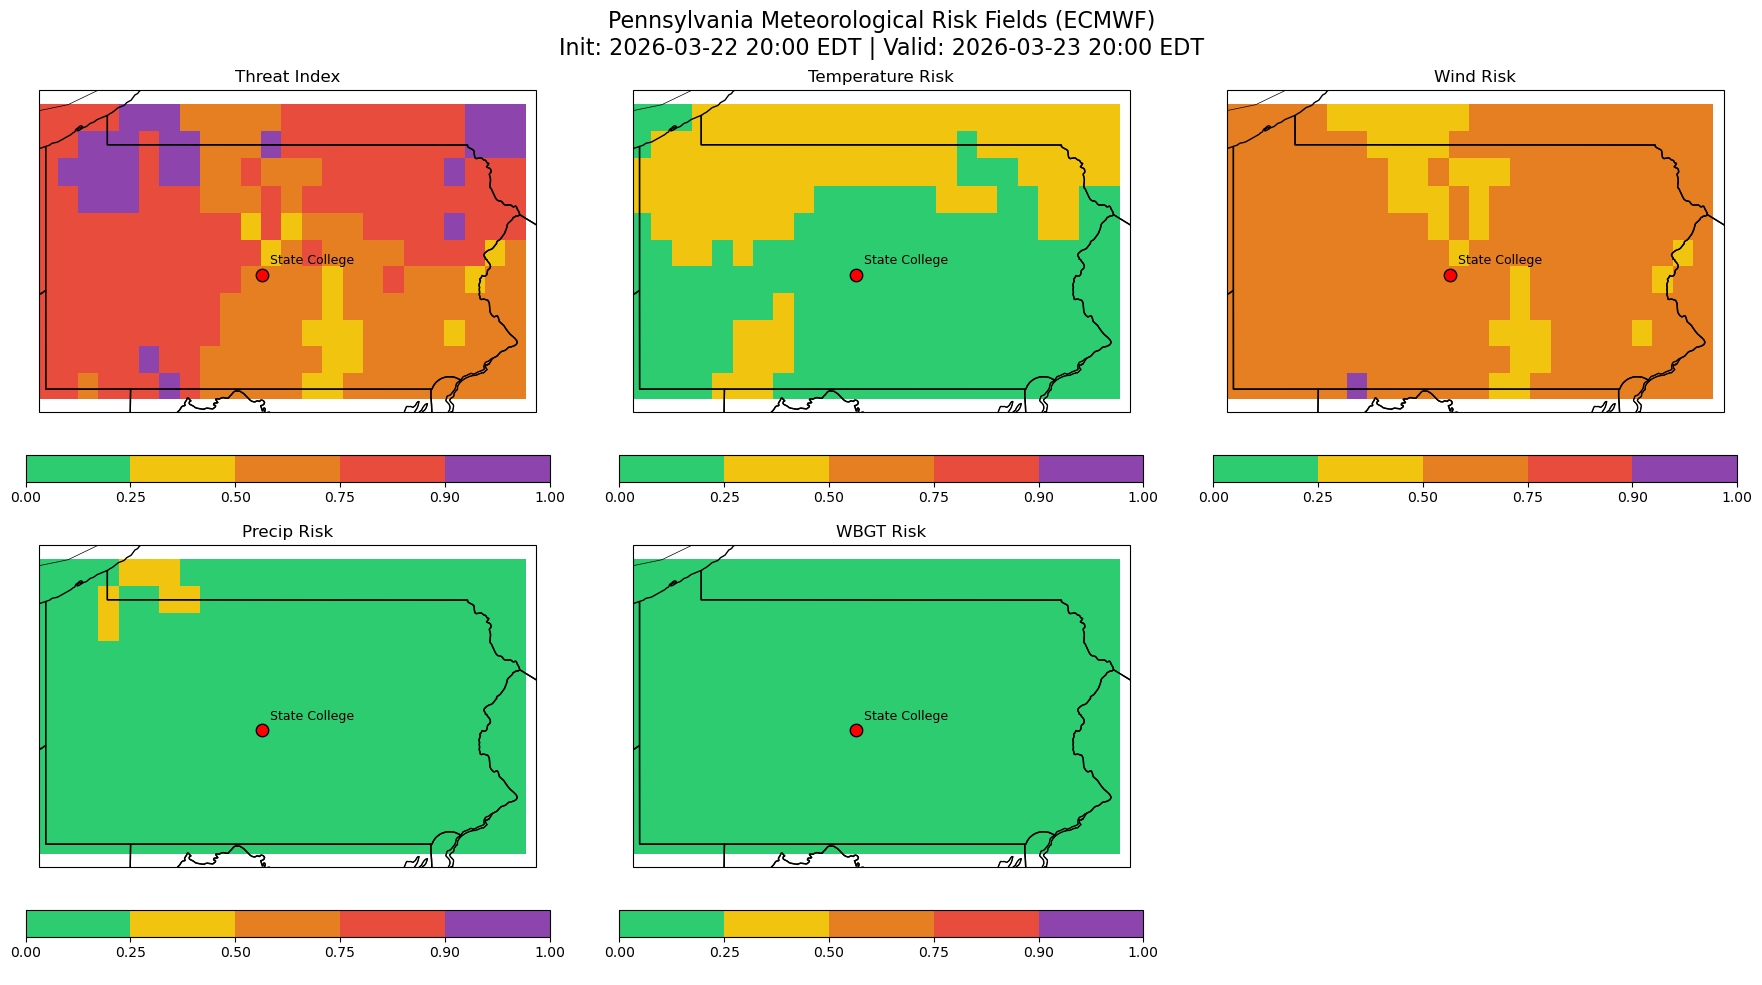

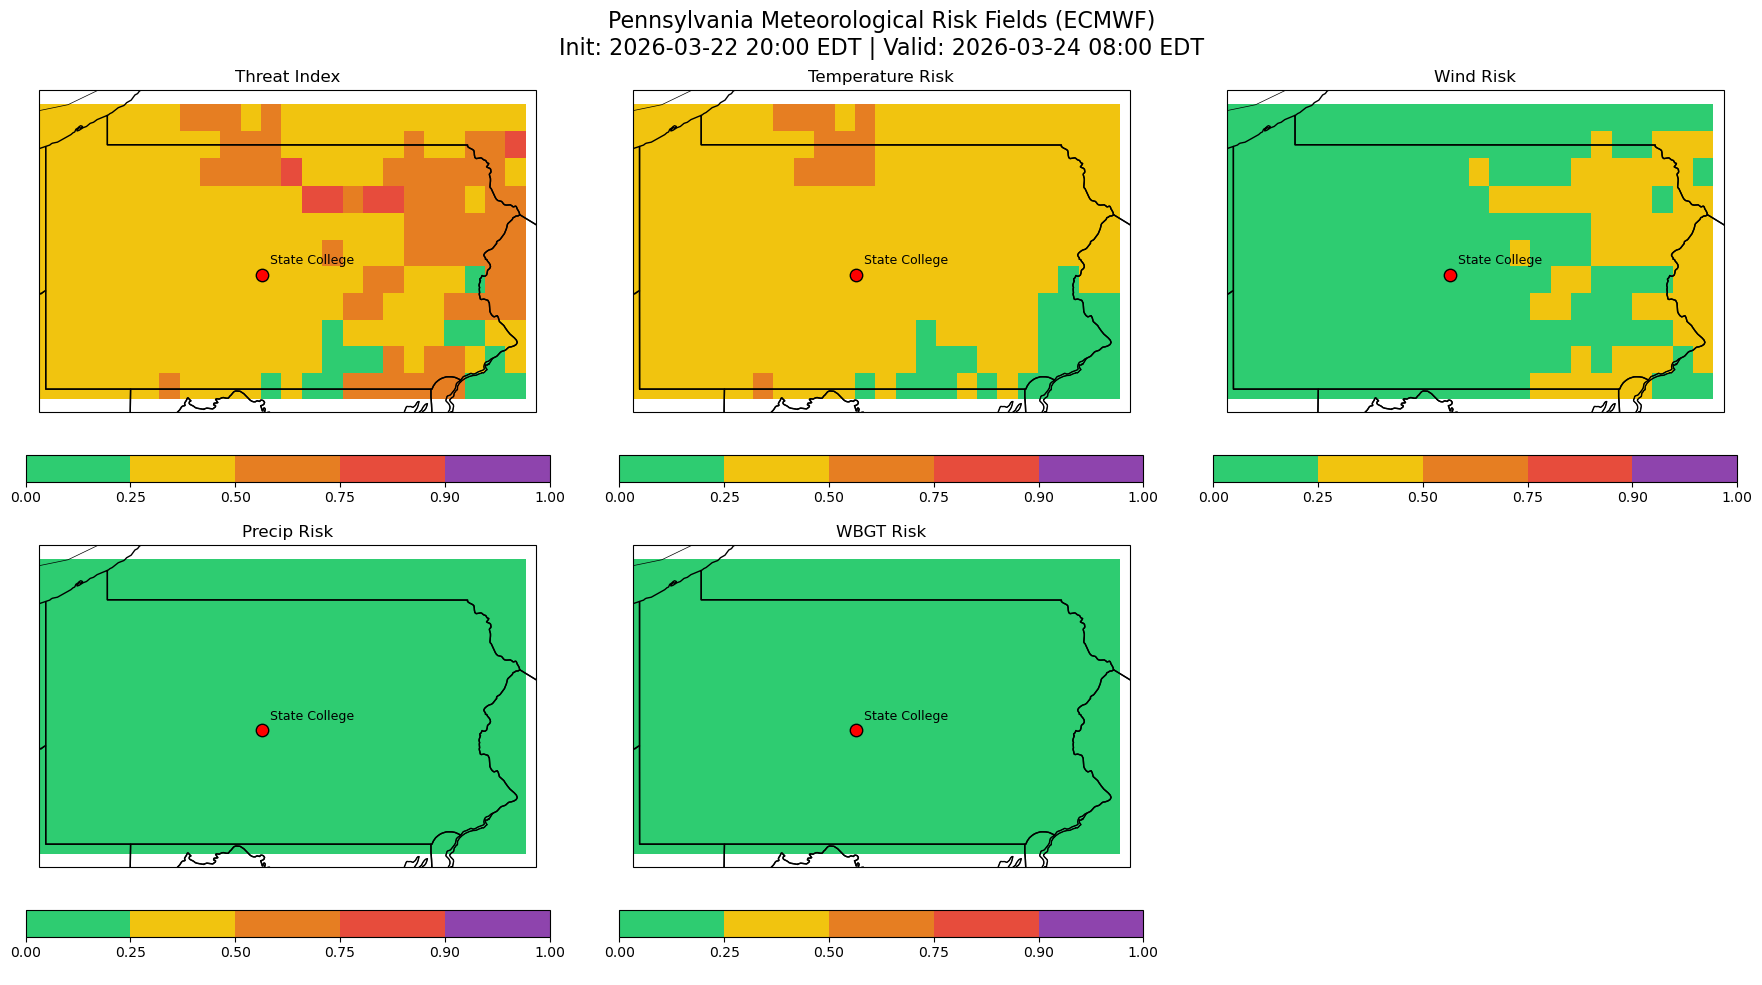

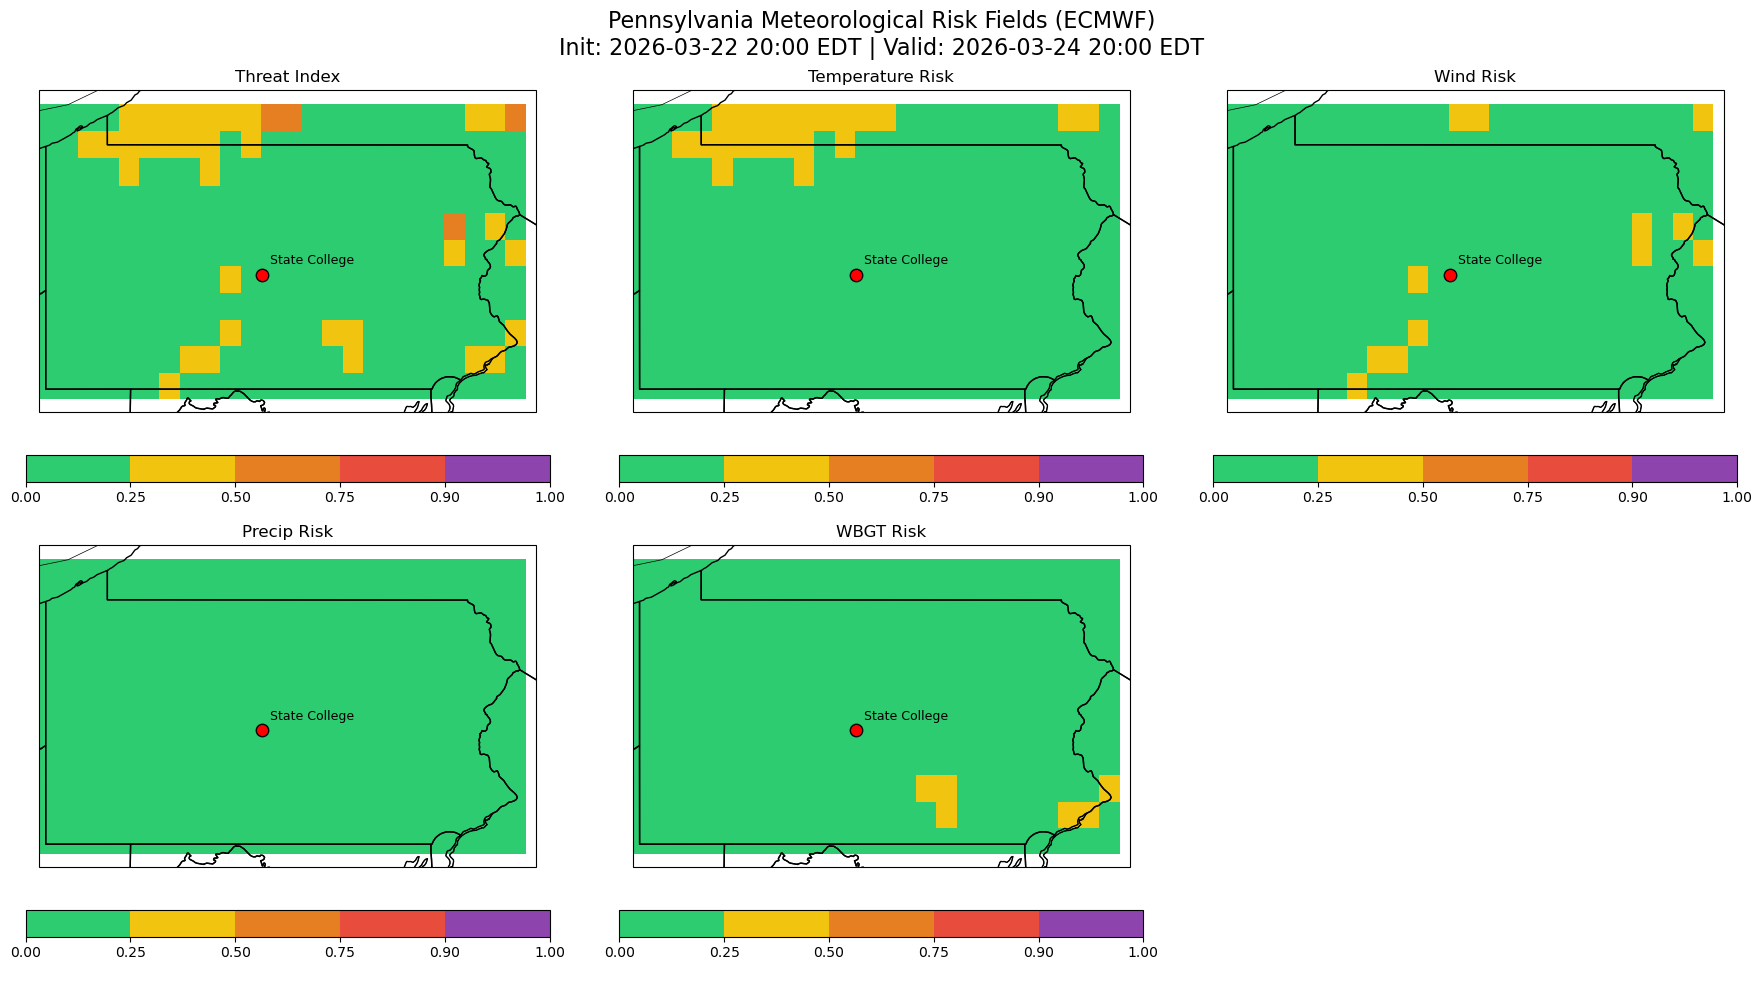

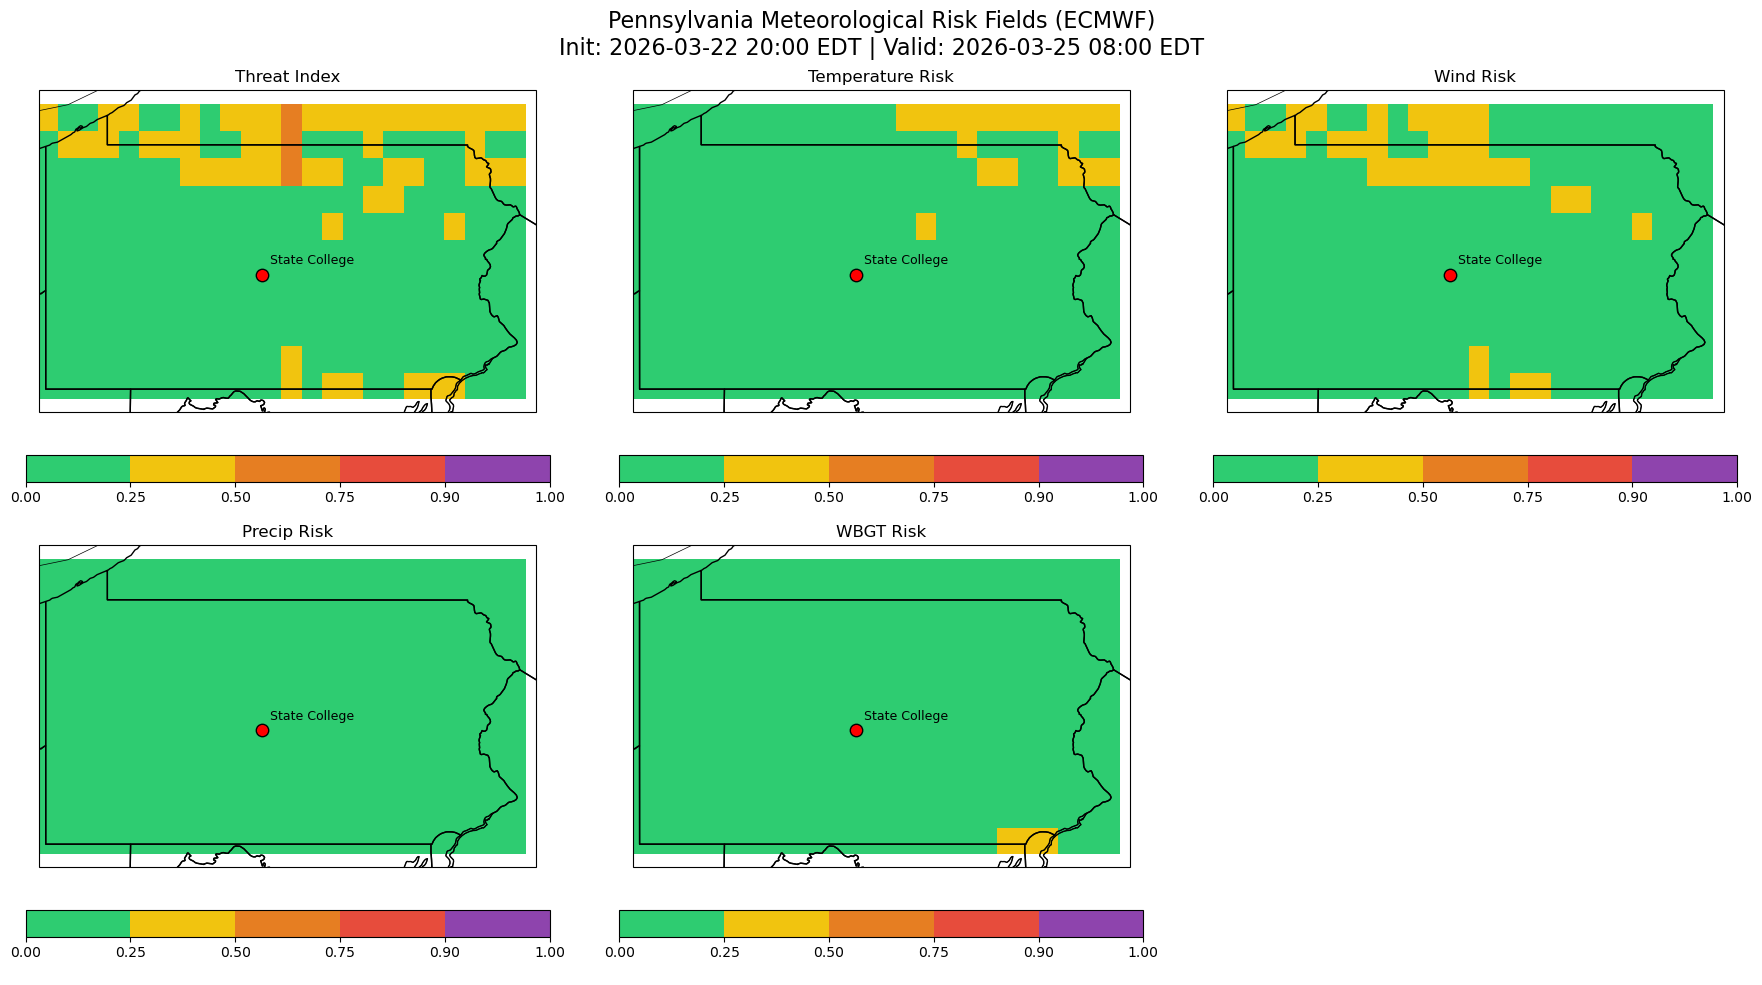

In [36]:
# ==============================
# PLOTTING (NOW GEOGRAPHIC)
# ==============================
for t_idx, i in enumerate(times_idx):

    valid_time = str(times_actual[t_idx])[:16]

    fig, axs = plt.subplots(
        2, 3, figsize=(18,10),
        subplot_kw={'projection': ccrs.Mercator()}
    )

    axs = axs.flatten()

    im0 = axs[0].pcolormesh(lon2d, lat2d, PUI_list[t_idx],
                           cmap=risk_cmap, norm=norm,
                           transform=ccrs.PlateCarree())
    axs[0].set_title("Threat Index")
    format_map(axs[0])
    plt.colorbar(im0, ax=axs[0],shrink=0.9, orientation='horizontal', pad=0.1)

    im1 = axs[1].pcolormesh(lon2d, lat2d, temp_risk_list[t_idx],
                           cmap=risk_cmap, norm=norm,
                           transform=ccrs.PlateCarree())
    axs[1].set_title("Temperature Risk")
    format_map(axs[1])
    plt.colorbar(im1, ax=axs[1],shrink=0.9, orientation='horizontal', pad=0.1)

    im2 = axs[2].pcolormesh(lon2d, lat2d, wind_risk_list[t_idx],
                           cmap=risk_cmap, norm=norm,
                           transform=ccrs.PlateCarree())
    axs[2].set_title("Wind Risk")
    format_map(axs[2])
    plt.colorbar(im2, ax=axs[2],shrink=0.9, orientation='horizontal', pad=0.1)

    im3 = axs[3].pcolormesh(lon2d, lat2d, precip_risk_list[t_idx],
                           cmap=risk_cmap, norm=norm,
                           transform=ccrs.PlateCarree())
    axs[3].set_title("Precip Risk")
    format_map(axs[3])
    plt.colorbar(im3, ax=axs[3],shrink=0.9, orientation='horizontal', pad=0.1)

    im4 = axs[4].pcolormesh(lon2d, lat2d, WBGT_risk_list[t_idx],
                           cmap=risk_cmap, norm=norm,
                           transform=ccrs.PlateCarree())
    axs[4].set_title("WBGT Risk")
    format_map(axs[4])
    plt.colorbar(im4, ax=axs[4],shrink=0.9, orientation='horizontal', pad=0.1)

    axs[5].axis('off')
    init_time = pd.to_datetime(ds2['time'].values).tz_localize('UTC').tz_convert('US/Eastern')
    valid_time_et = pd.to_datetime(valid_time).tz_localize('UTC').tz_convert('US/Eastern')

    fig.suptitle(
    f"Pennsylvania Meteorological Risk Fields (ECMWF)\n"
    f"Init: {init_time.strftime('%Y-%m-%d %H:%M %Z')} | "
    f"Valid: {valid_time_et.strftime('%Y-%m-%d %H:%M %Z')}",
    fontsize=16
    )
   
    filename = f"March_{i:03d}.png"
    plt.savefig(filename, dpi=100, bbox_inches="tight")
    plt.tight_layout()
    plt.show()

In [28]:
#Calling variables for next run
ds_a = xr.open_dataset("10fgJanBadecmwf_20260125Jan.nc")
ds_b = xr.open_dataset("JanBadecmwf_20260125Jan.nc")
ds2 = xr.merge([ds_a, ds_b], compat = 'override')
ds2

sh: 1: getfattr: not found
sh: 1: getfattr: not found


<xarray.Dataset> Size: 80kB
Dimensions:            (valid_time: 15, latitude: 11, longitude: 24)
Coordinates:
  * valid_time         (valid_time) datetime64[ns] 120B 2026-01-25 ... 2026-0...
  * latitude           (latitude) float64 88B 42.25 42.0 41.75 ... 40.0 39.75
  * longitude          (longitude) float64 192B -80.5 -80.25 ... -75.0 -74.75
    time               datetime64[ns] 8B ...
    step               (valid_time) timedelta64[ns] 120B ...
    heightAboveGround  float64 8B ...
    surface            float64 8B ...
Data variables:
    fg10               (valid_time, latitude, longitude) float32 16kB ...
    tp                 (valid_time, latitude, longitude) float32 16kB ...
    sf                 (valid_time, latitude, longitude) float32 16kB ...
    t2m                (valid_time, latitude, longitude) float32 16kB ...
    d2m                (valid_time, latitude, longitude) float32 16kB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-04-08T17:20 GRIB to CDM+CF via cfgrib-0.9.1...

In [29]:
# ==============================
# SELECT TIME STEPS
# ==============================
times_idx = [0, 2, 4, 6, 8, 10]
times_actual = ds2.valid_time.values[times_idx]

# ==============================
# STORAGE
# ==============================
PUI_list = []
temp_risk_list = []
wind_risk_list = []
precip_risk_list = []
WBGT_risk_list = []


In [30]:
# ==============================
# LOOP (UNCHANGED LOGIC)
# ==============================
for i in times_idx:

    tempf2d = (ds2['t2m'].isel(valid_time=i).values - 273.15)*(9/5)+32
    dewf2d = (ds2['d2m'].isel(valid_time=i).values - 273.15)*(9/5)+32
    windgust2d = ds2['fg10'].isel(valid_time=i).values * 2.2369

    if i > 0:
        accum_precip = (
            ds2['tp'].isel(valid_time=i).values -
            ds2['tp'].isel(valid_time=i-1).values
        ) * 39.37
    else:
        accum_precip = ds2['tp'].isel(valid_time=i).values * 39.37

    RH = calc_rh(tempf2d, dewf2d)
    Tw = wet_bulb_temp(tempf2d, RH)
    WBGT = (wbgt_calc(T_c, Tw, Tg)*1.8)+32

    # --- Temperature Risk ---
    temp_risk = np.zeros_like(tempf2d)
    temp_risk[tempf2d < 40] = (40 - tempf2d[tempf2d < 40]) / 40
    mask = (tempf2d >= 40) & (tempf2d <= 75)
    temp_risk[mask] = 0
    mask = tempf2d > 75
    temp_risk[mask] = (tempf2d[mask] - 75) / 25
    temp_risk = np.clip(temp_risk, 0, 1)

    # --- WBGT Risk ---
    WBGT_risk = np.zeros_like(WBGT)
    WBGT_risk[(WBGT >= 80) & (WBGT < 85)] = 0.25
    WBGT_risk[(WBGT >= 85) & (WBGT < 88)] = 0.5
    WBGT_risk[(WBGT >= 88) & (WBGT < 90)] = 0.75
    WBGT_risk[WBGT >= 90] = 1.0

    # --- Wind Risk ---
    wind_risk = np.zeros_like(windgust2d)
    wind_risk[(windgust2d >= 15) & (windgust2d < 25)] = 0.3
    wind_risk[(windgust2d >= 25) & (windgust2d < 40)] = 0.6
    wind_risk[windgust2d >= 40] = 1.0

    # --- Precip Risk ---
    precip_risk = np.zeros_like(accum_precip)
    precip_risk[(accum_precip >= 0.05) & (accum_precip < 0.25)] = 0.3
    precip_risk[(accum_precip >= 0.25) & (accum_precip < 0.75)] = 0.6
    precip_risk[accum_precip >= 0.75] = 1.0

    temp_risk = np.nan_to_num(temp_risk)
    wind_risk = np.nan_to_num(wind_risk)
    precip_risk = np.nan_to_num(precip_risk)

    PUI = temp_risk + wind_risk + precip_risk + WBGT_risk
    PUI = np.nan_to_num(PUI)

    PUI_list.append(PUI)
    temp_risk_list.append(temp_risk)
    wind_risk_list.append(wind_risk)
    precip_risk_list.append(precip_risk)
    WBGT_risk_list.append(WBGT_risk)


In [31]:
# ==============================
# MAP FORMAT FUNCTION
# ==============================
def format_map(ax):
    ax.set_extent([-80.6, -74.5, 39.5, 42.5])
    ax.add_feature(cfeature.STATES, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)

    # --- State College dot ---
    ax.scatter(
        sc_lon, sc_lat,
        color='red',
        s=80,
        edgecolor='black',
        transform=ccrs.PlateCarree(),
        zorder=10
    )

    ax.text(
        sc_lon + 0.1, sc_lat + 0.1,
        "State College",
        fontsize=9,
        transform=ccrs.PlateCarree()
    )


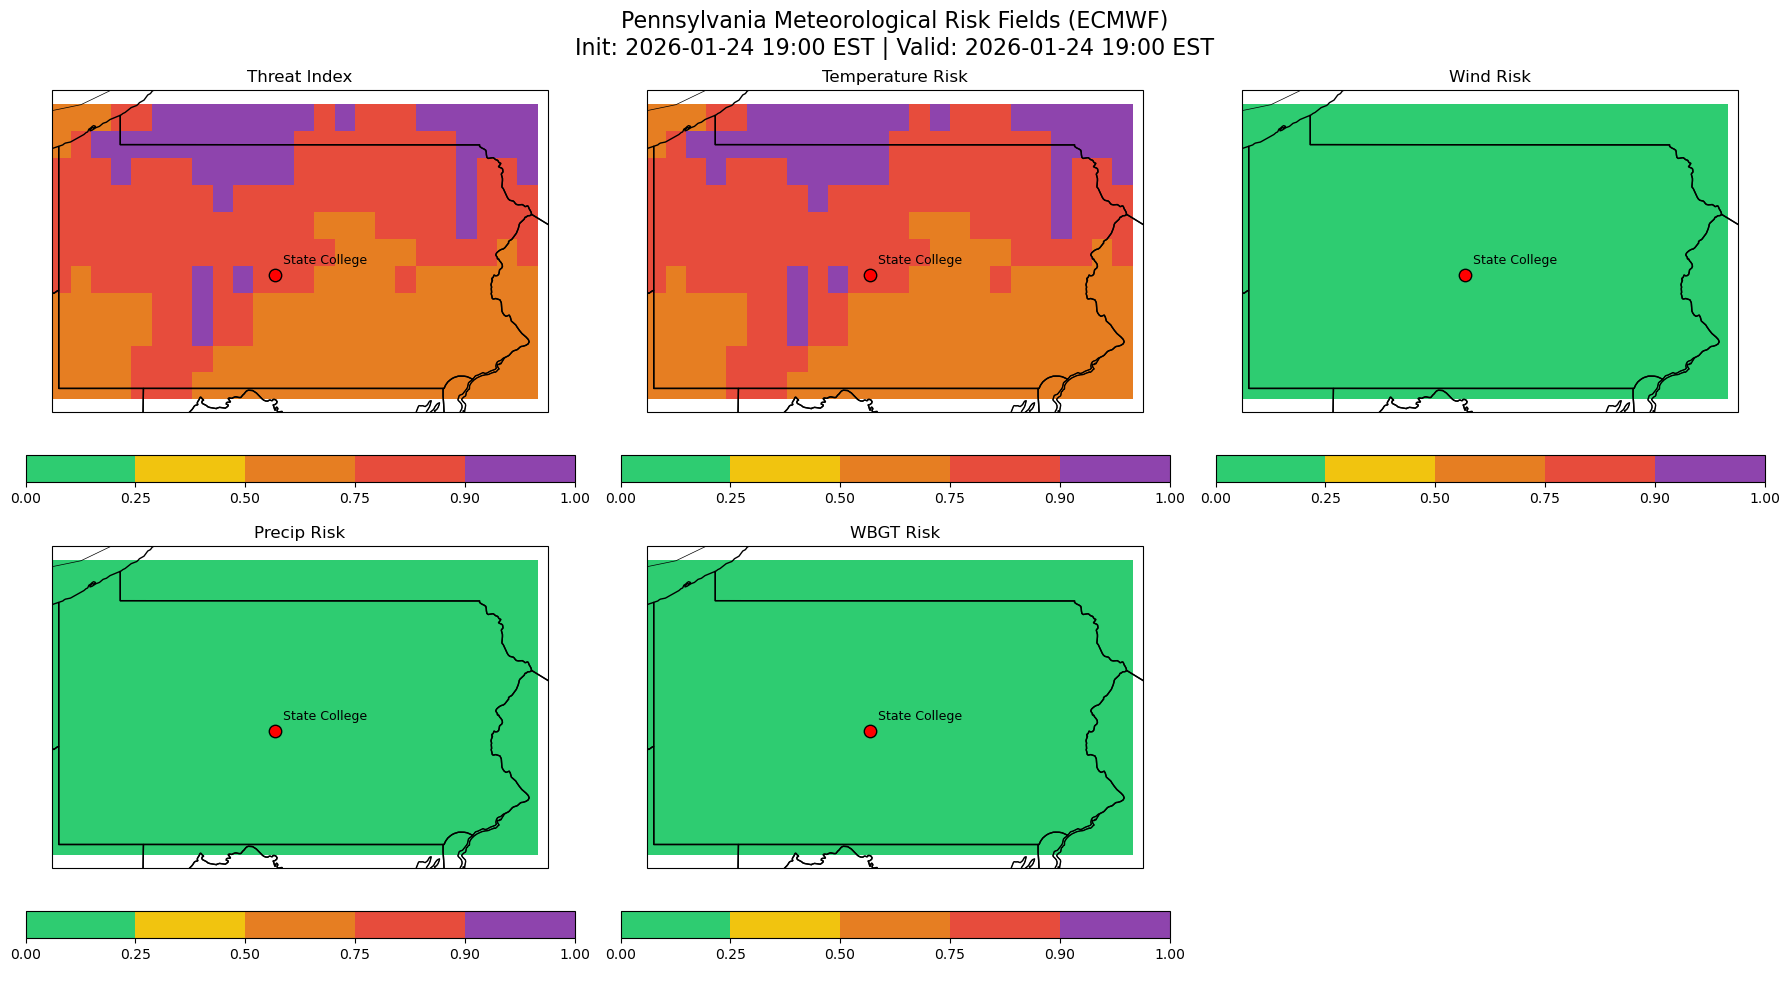

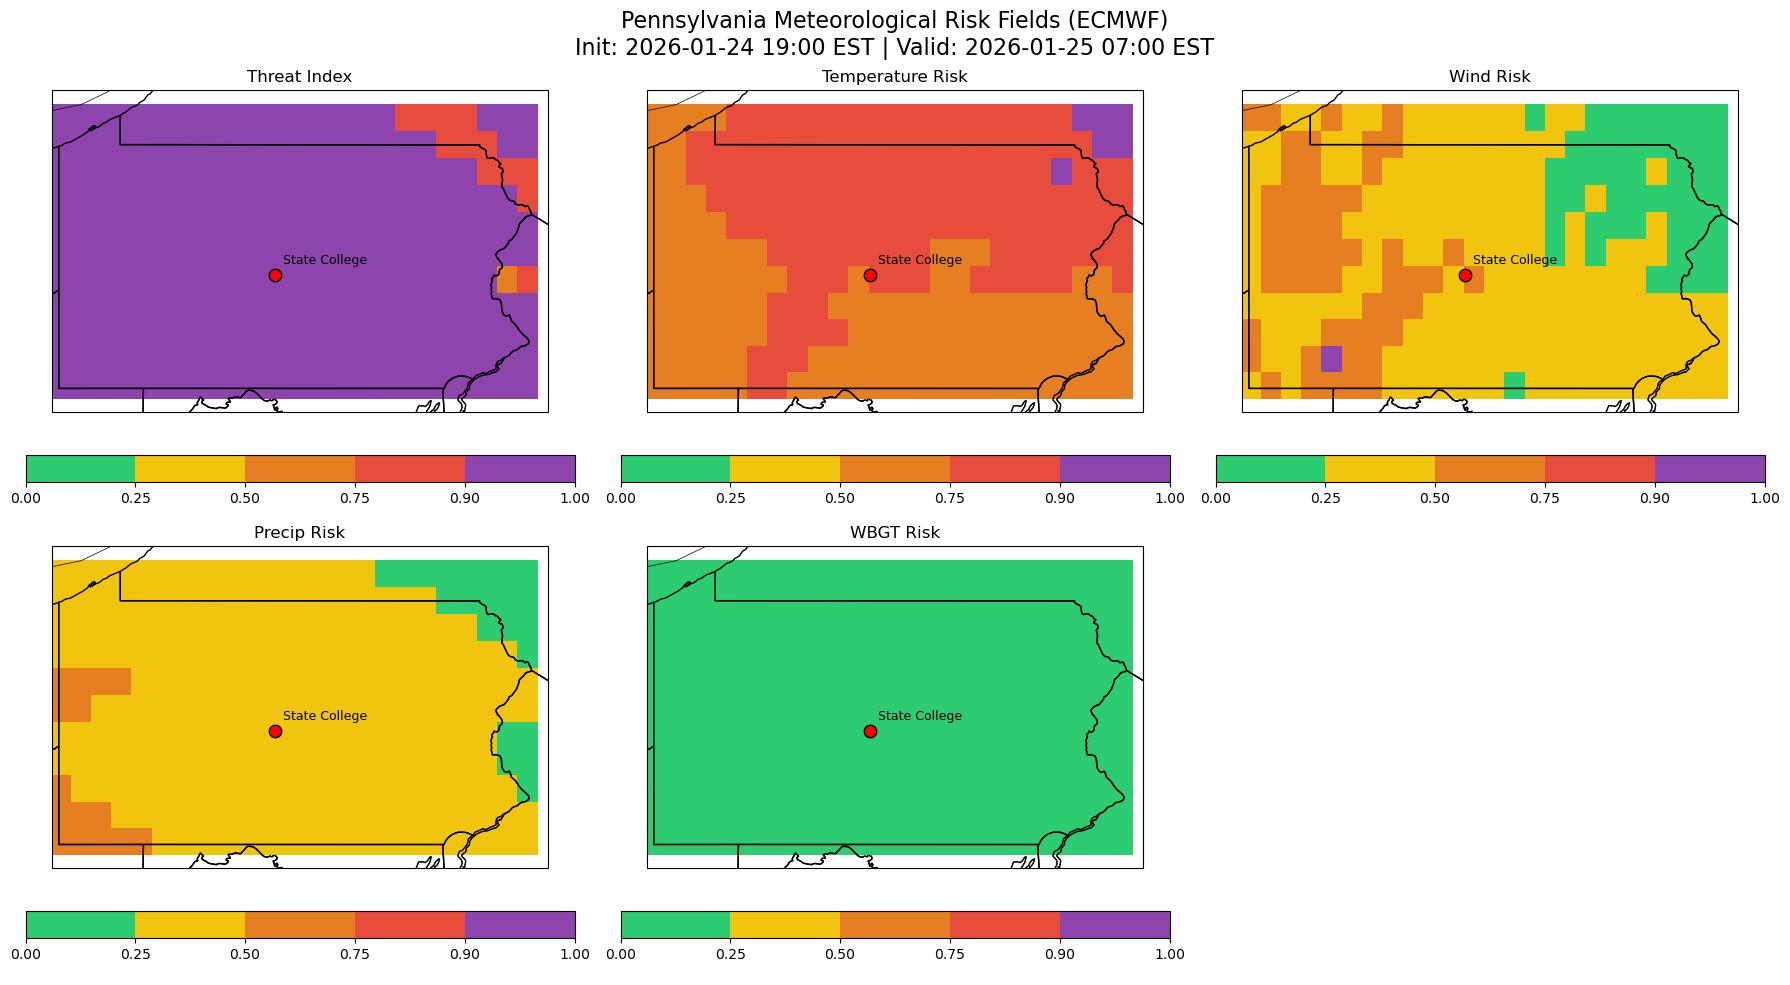

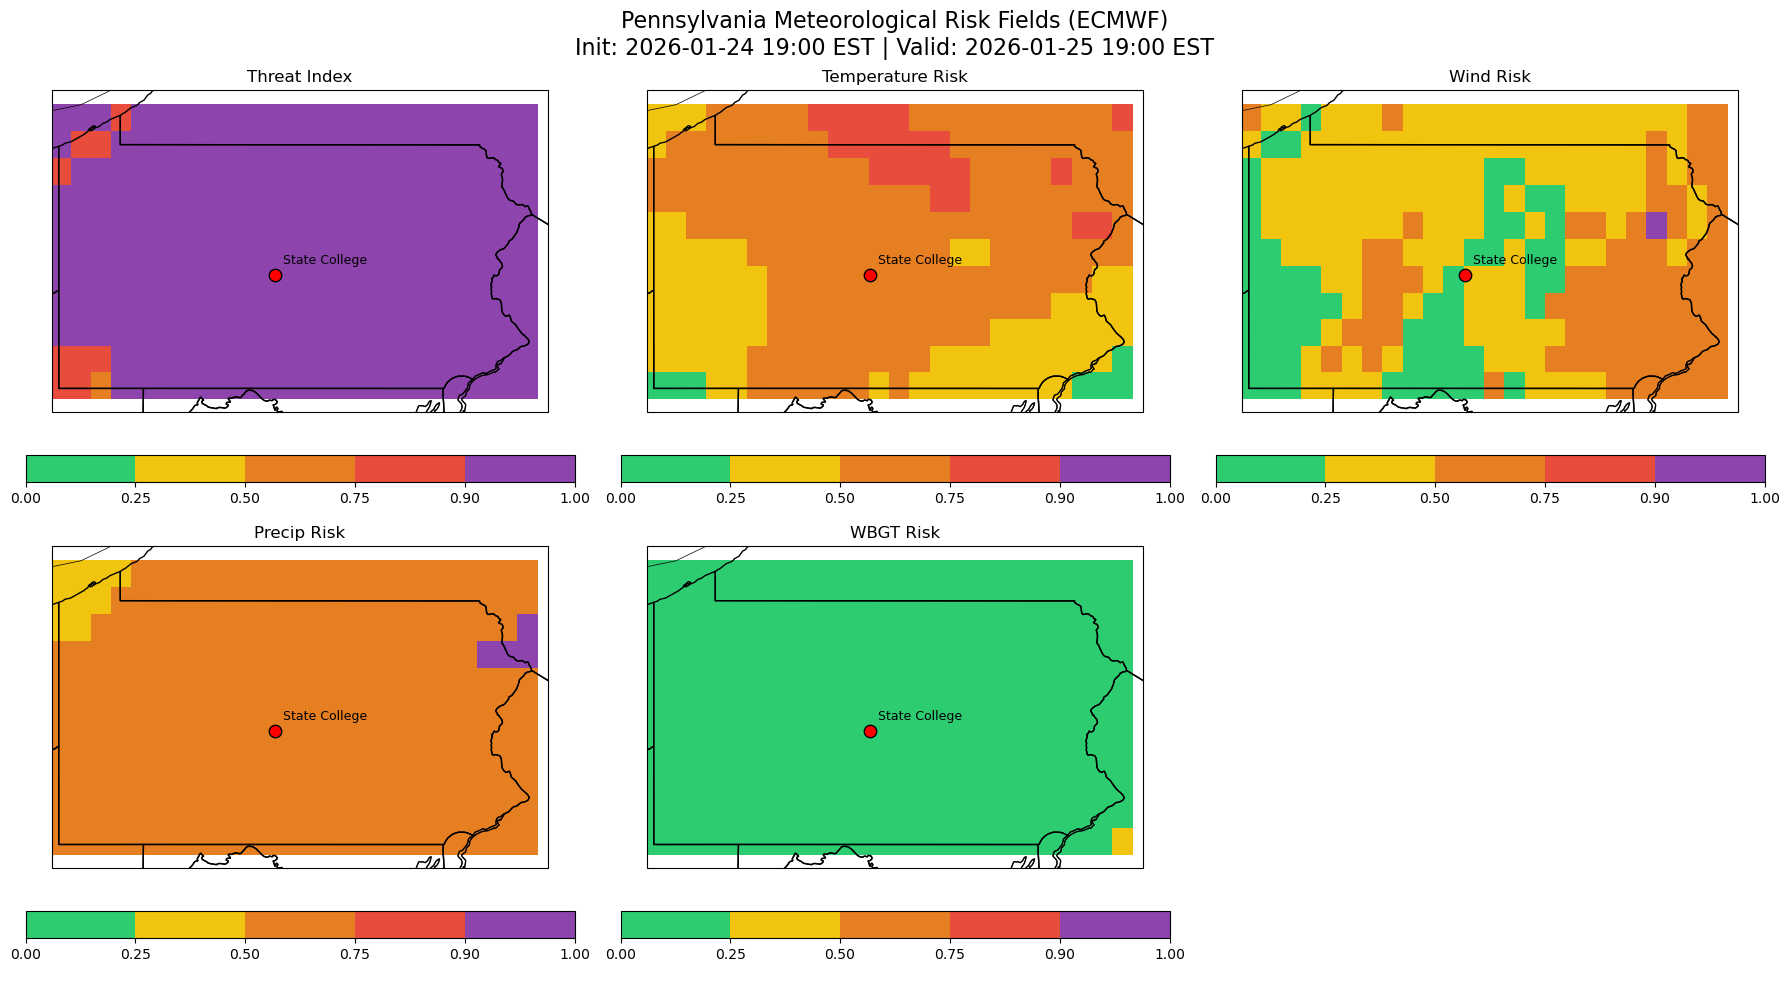

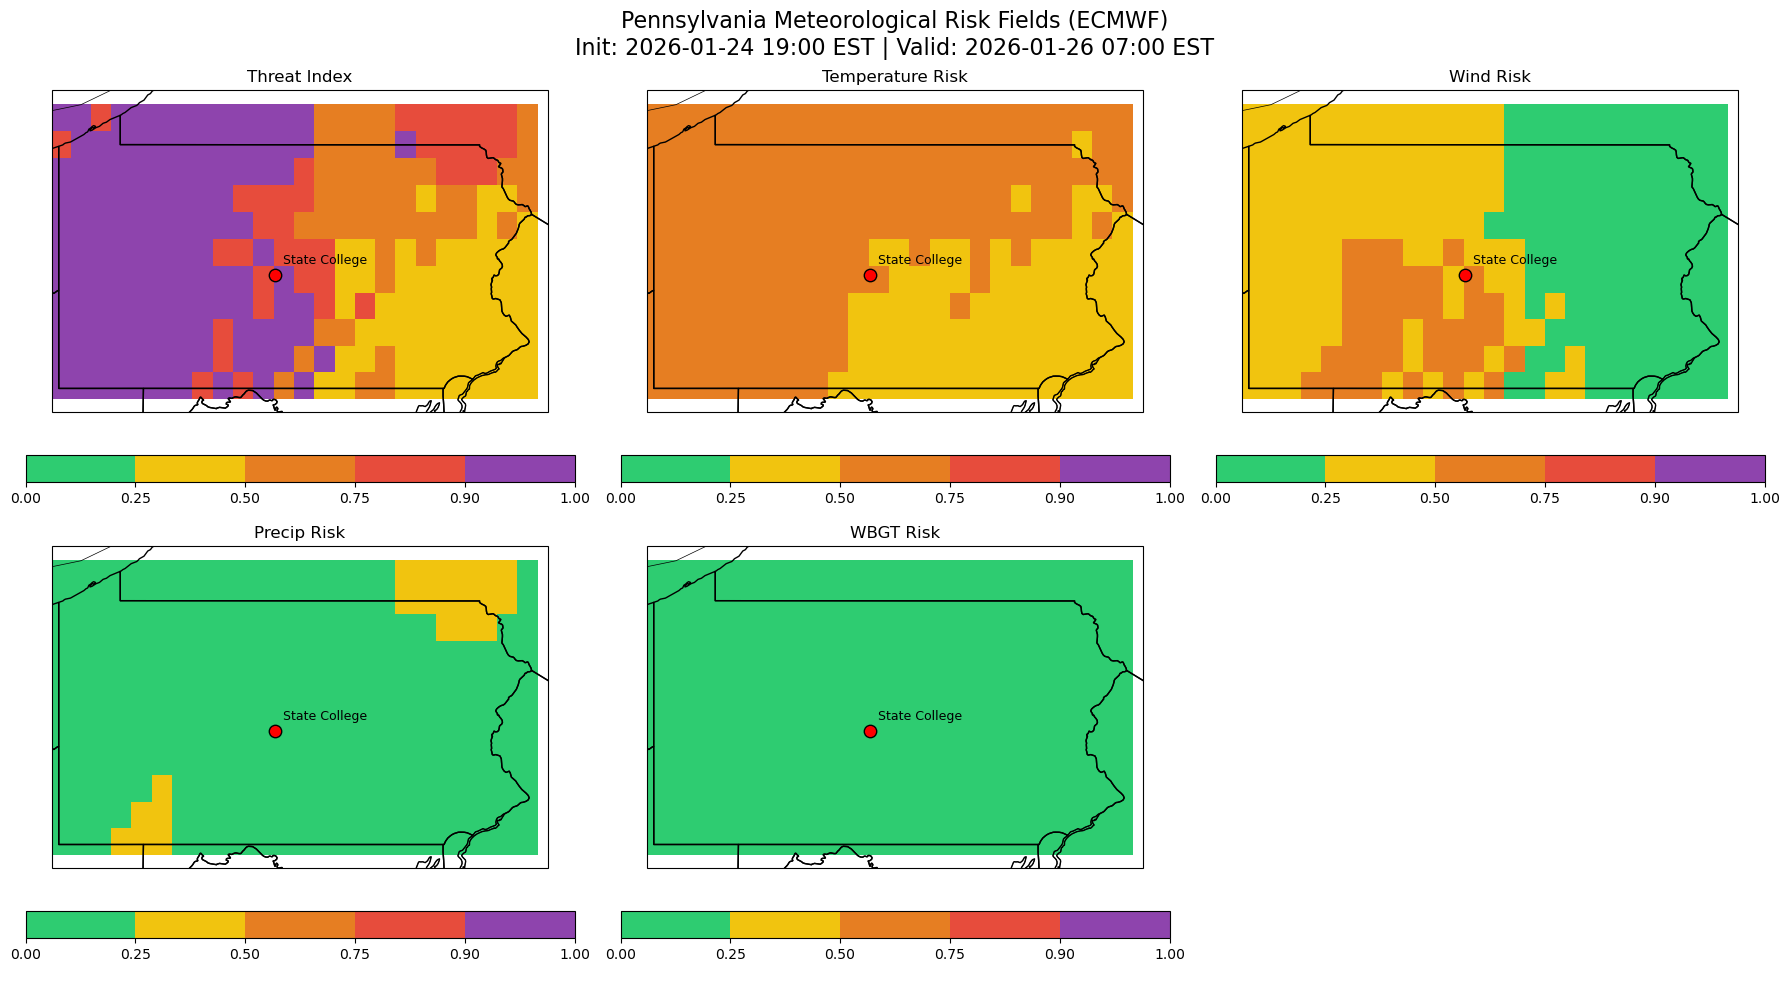

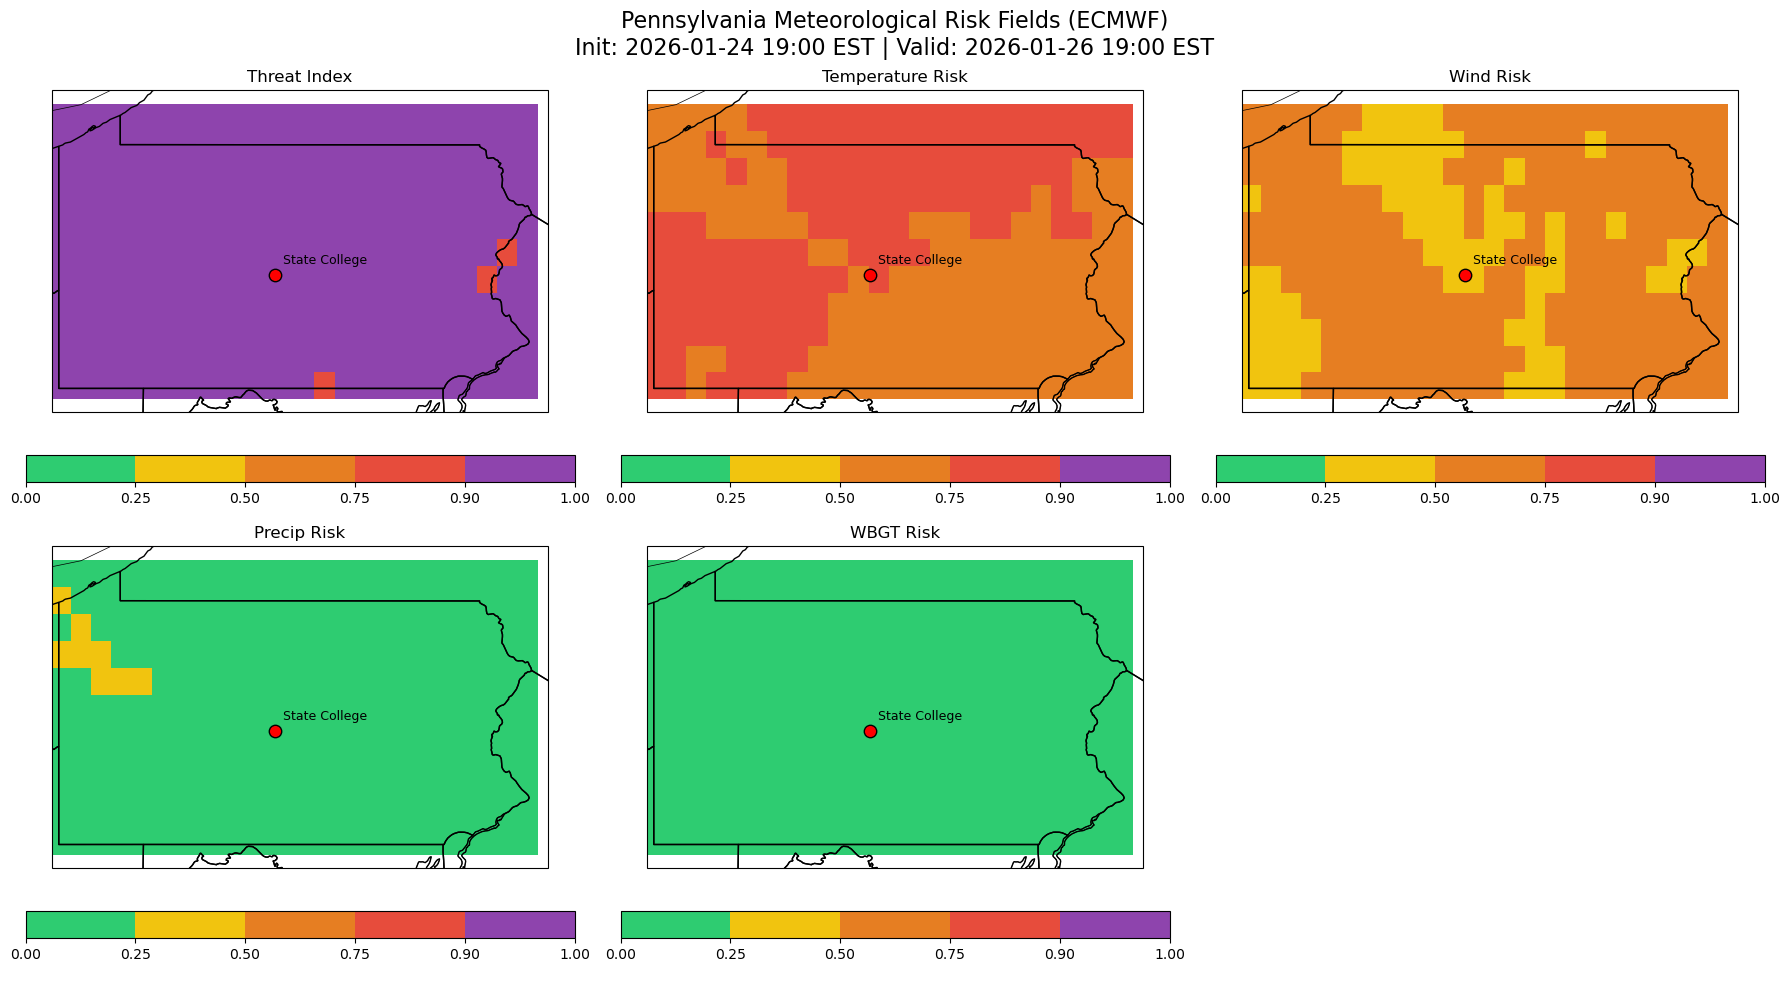

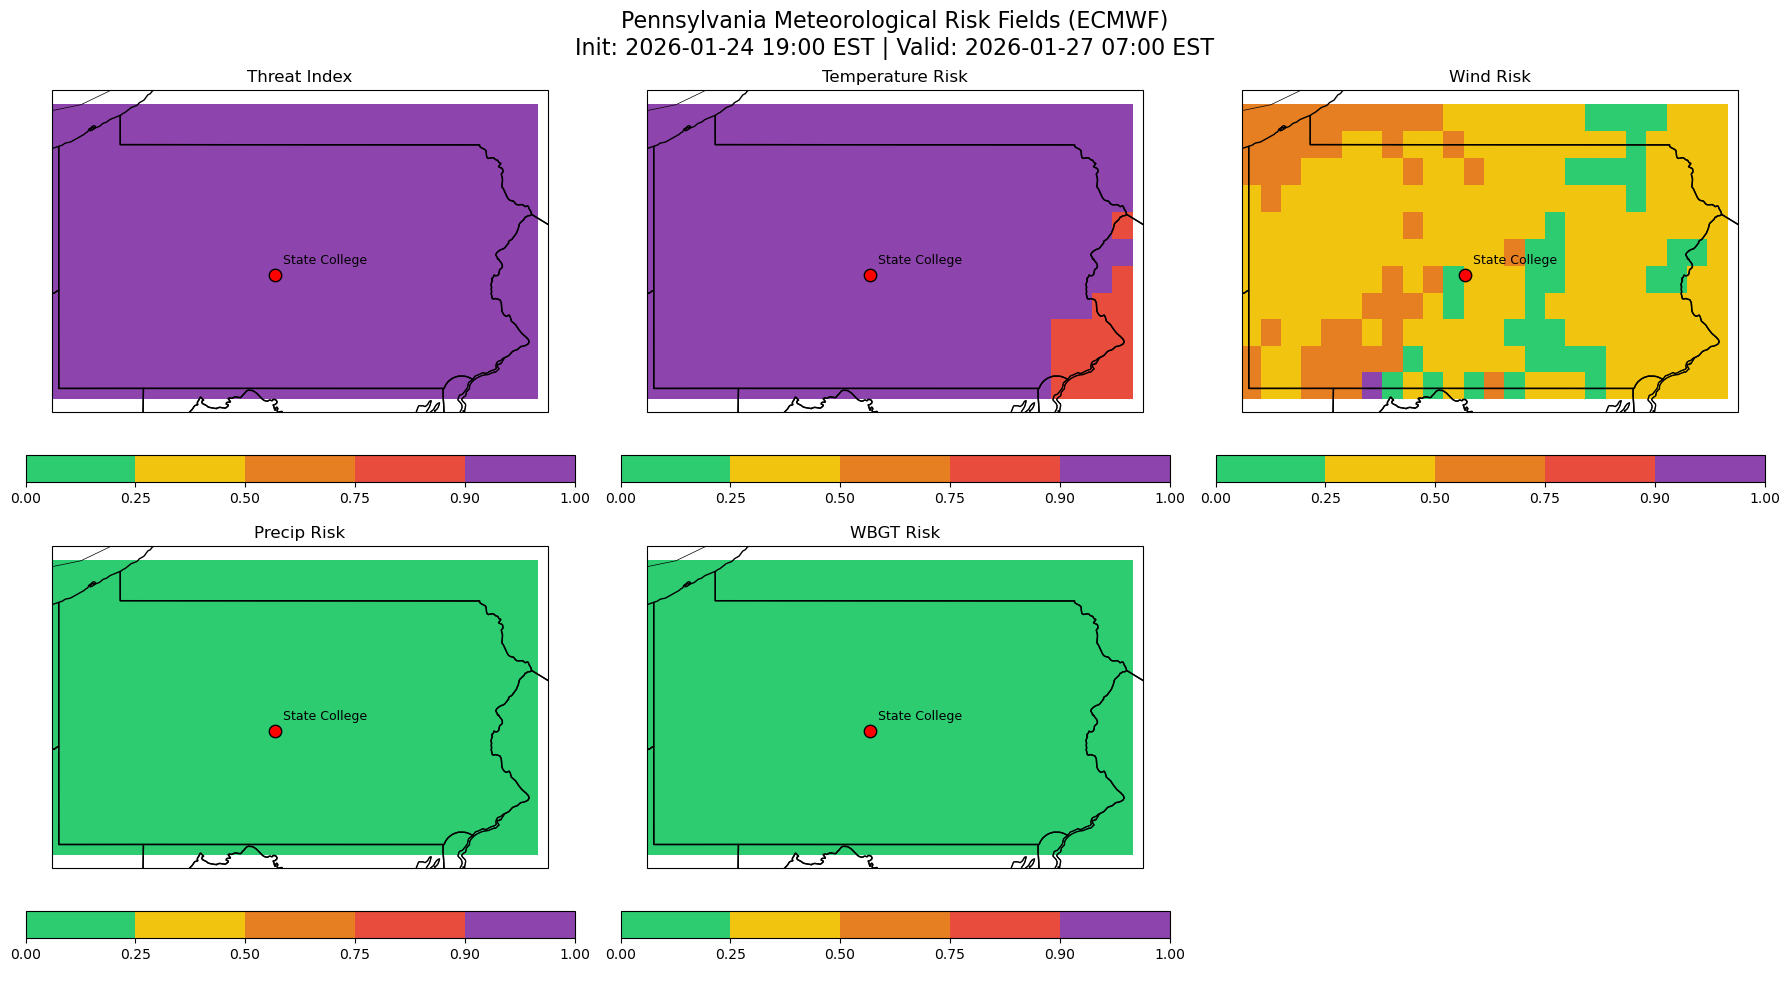

In [32]:



# ==============================
# PLOTTING (NOW GEOGRAPHIC)
# ==============================
for t_idx, i in enumerate(times_idx):

    valid_time = str(times_actual[t_idx])[:16]

    fig, axs = plt.subplots(
        2, 3, figsize=(18,10),
        subplot_kw={'projection': ccrs.Mercator()}
    )

    axs = axs.flatten()

    im0 = axs[0].pcolormesh(lon2d, lat2d, PUI_list[t_idx],
                           cmap=risk_cmap, norm=norm,
                           transform=ccrs.PlateCarree())
    axs[0].set_title("Threat Index")
    format_map(axs[0])
    plt.colorbar(im0, ax=axs[0], orientation='horizontal', pad=0.1)

    im1 = axs[1].pcolormesh(lon2d, lat2d, temp_risk_list[t_idx],
                           cmap=risk_cmap, norm=norm,
                           transform=ccrs.PlateCarree())
    axs[1].set_title("Temperature Risk")
    format_map(axs[1])
    plt.colorbar(im1, ax=axs[1], orientation='horizontal', pad=0.1)

    im2 = axs[2].pcolormesh(lon2d, lat2d, wind_risk_list[t_idx],
                           cmap=risk_cmap, norm=norm,
                           transform=ccrs.PlateCarree())
    axs[2].set_title("Wind Risk")
    format_map(axs[2])
    plt.colorbar(im2, ax=axs[2], orientation='horizontal', pad=0.1)

    im3 = axs[3].pcolormesh(lon2d, lat2d, precip_risk_list[t_idx],
                           cmap=risk_cmap, norm=norm,
                           transform=ccrs.PlateCarree())
    axs[3].set_title("Precip Risk")
    format_map(axs[3])
    plt.colorbar(im3, ax=axs[3], orientation='horizontal', pad=0.1)

    im4 = axs[4].pcolormesh(lon2d, lat2d, WBGT_risk_list[t_idx],
                           cmap=risk_cmap, norm=norm,
                           transform=ccrs.PlateCarree())
    axs[4].set_title("WBGT Risk")
    format_map(axs[4])
    plt.colorbar(im4, ax=axs[4], orientation='horizontal', pad=0.1)

    axs[5].axis('off')

    init_time = pd.to_datetime(ds2['time'].values).tz_localize('UTC').tz_convert('US/Eastern')
    valid_time_et = pd.to_datetime(valid_time).tz_localize('UTC').tz_convert('US/Eastern')

    fig.suptitle(
    f"Pennsylvania Meteorological Risk Fields (ECMWF)\n"
    f"Init: {init_time.strftime('%Y-%m-%d %H:%M %Z')} | "
    f"Valid: {valid_time_et.strftime('%Y-%m-%d %H:%M %Z')}",
    fontsize=16
    )
    filename = f"January_{i:03d}.png"
    plt.savefig(filename, dpi=100, bbox_inches="tight")
    
    plt.tight_layout()
    plt.show()

In [26]:
#calling variables for next run
ds_a = xr.open_dataset("AprCalmVarecmwf_20260406Apr.nc")
ds_b = xr.open_dataset("AprCalmecmwf_20260406Apr.nc")
ds2 = xr.merge([ds_a, ds_b], compat = 'override')


sh: 1: getfattr: not found
sh: 1: getfattr: not found


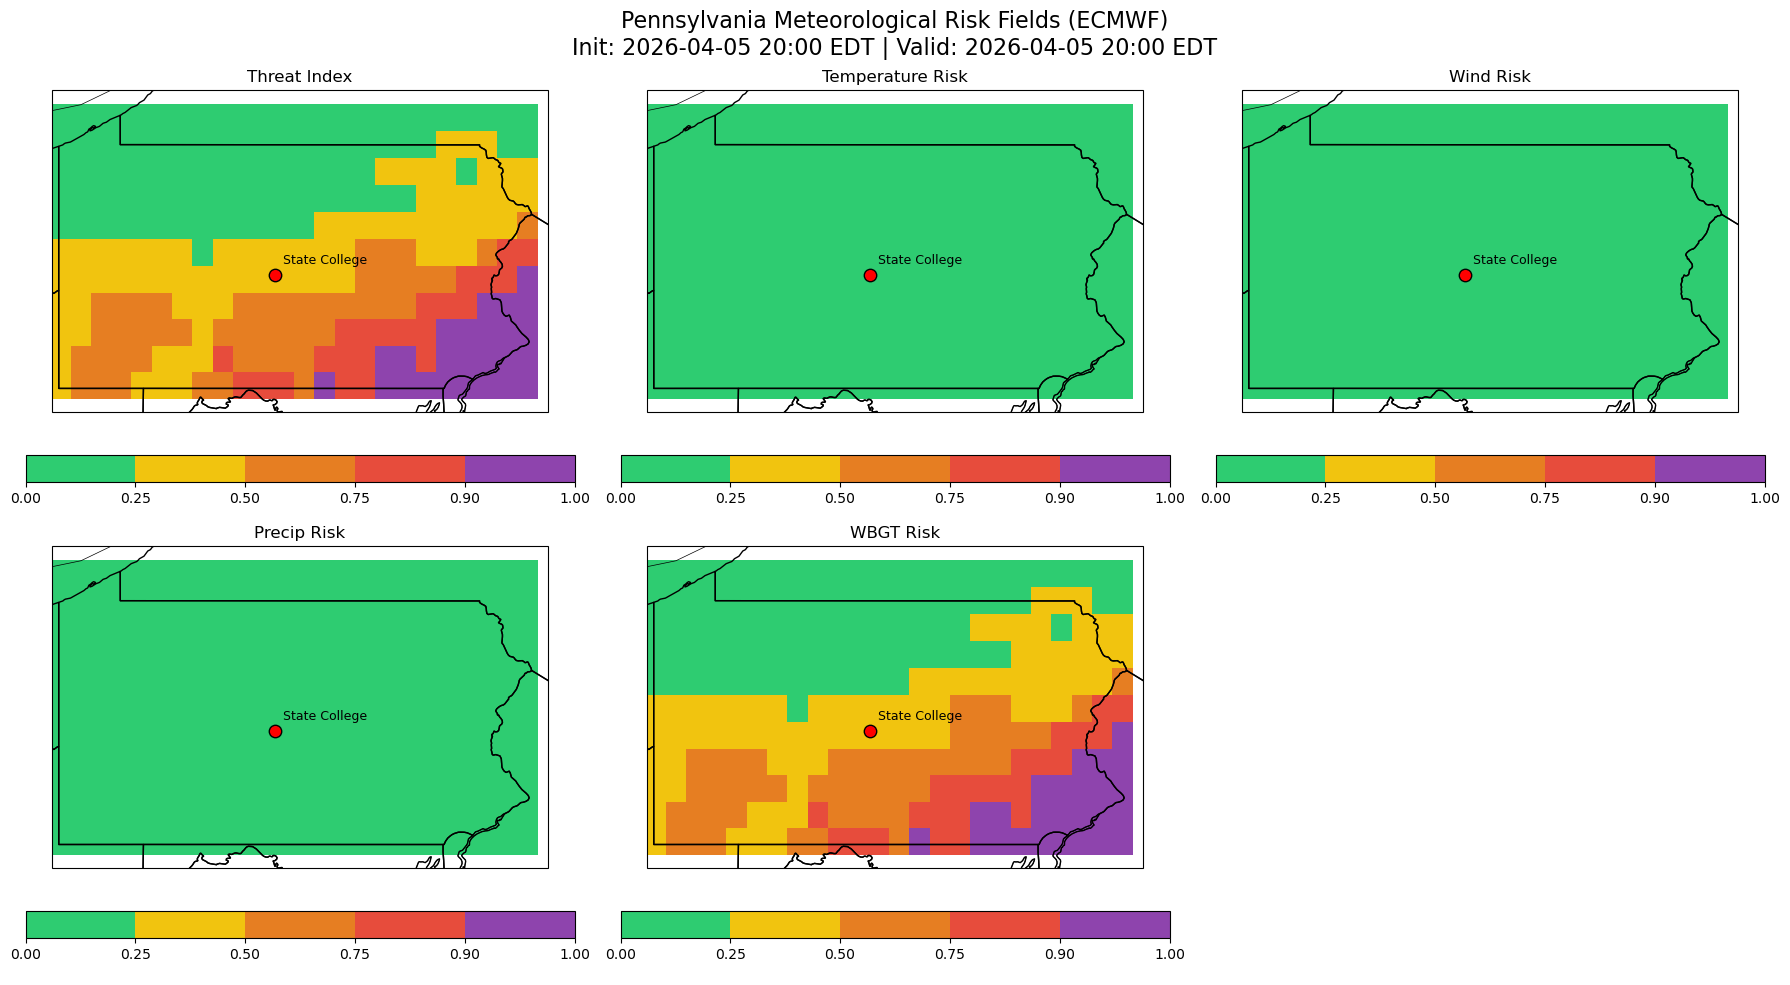

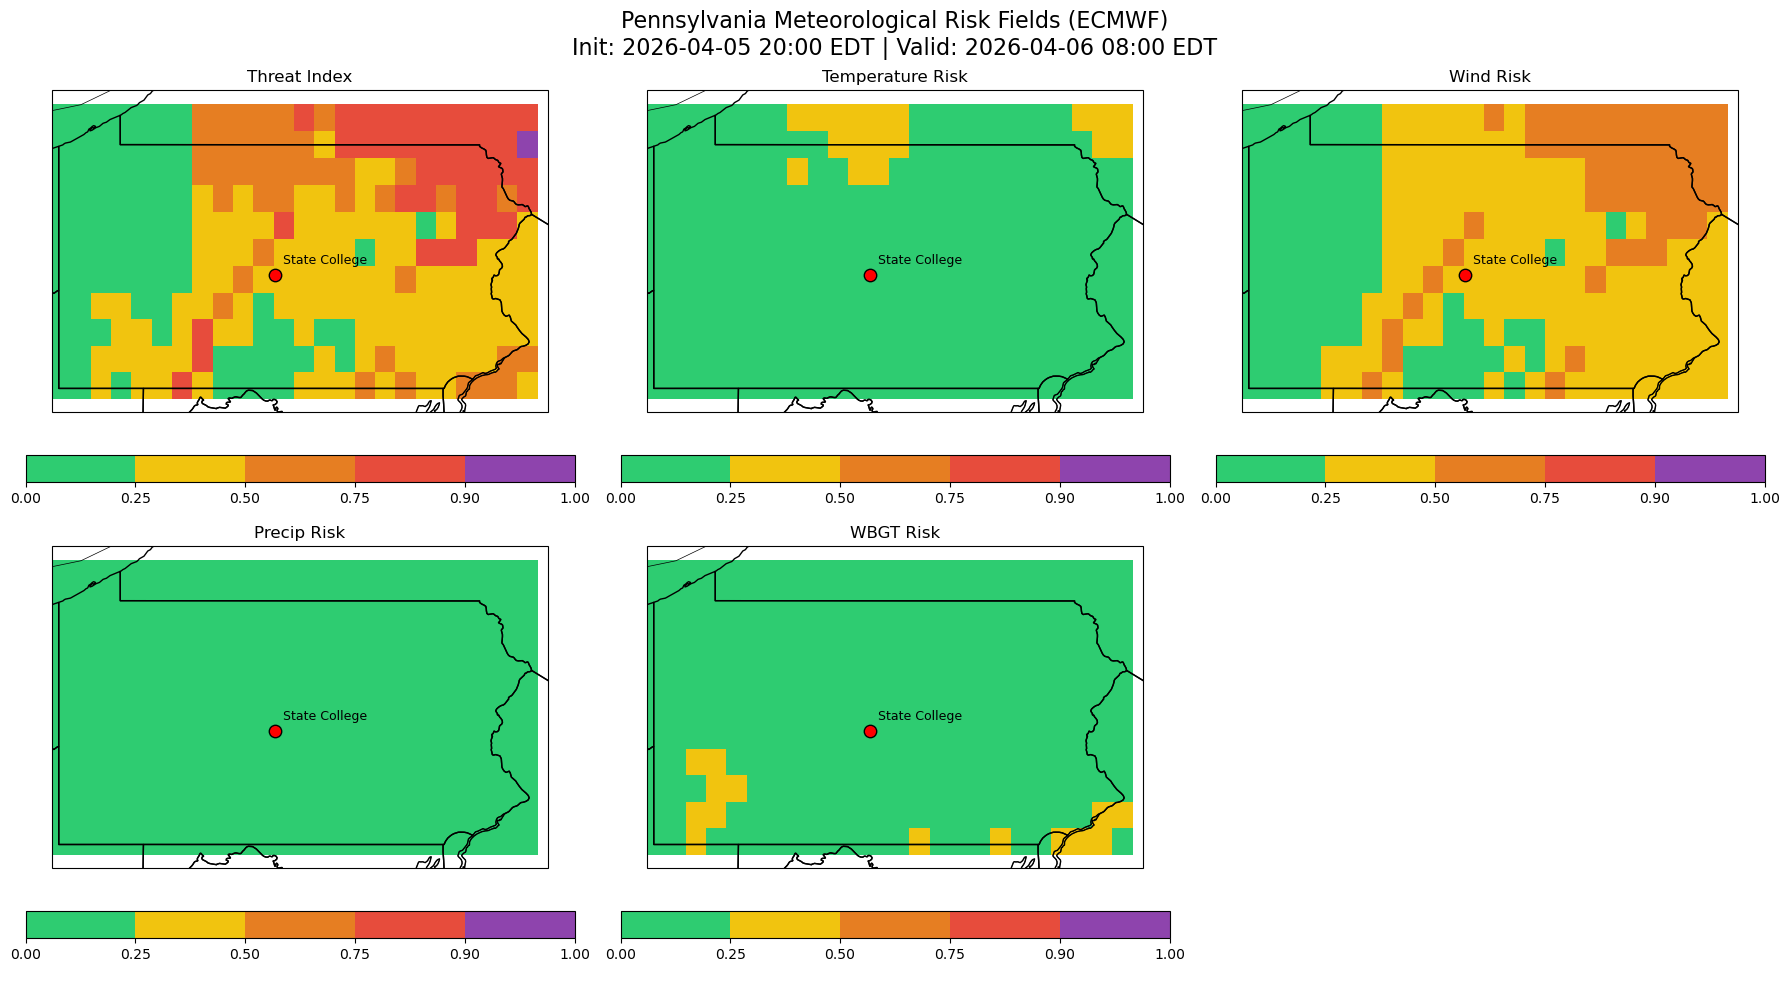

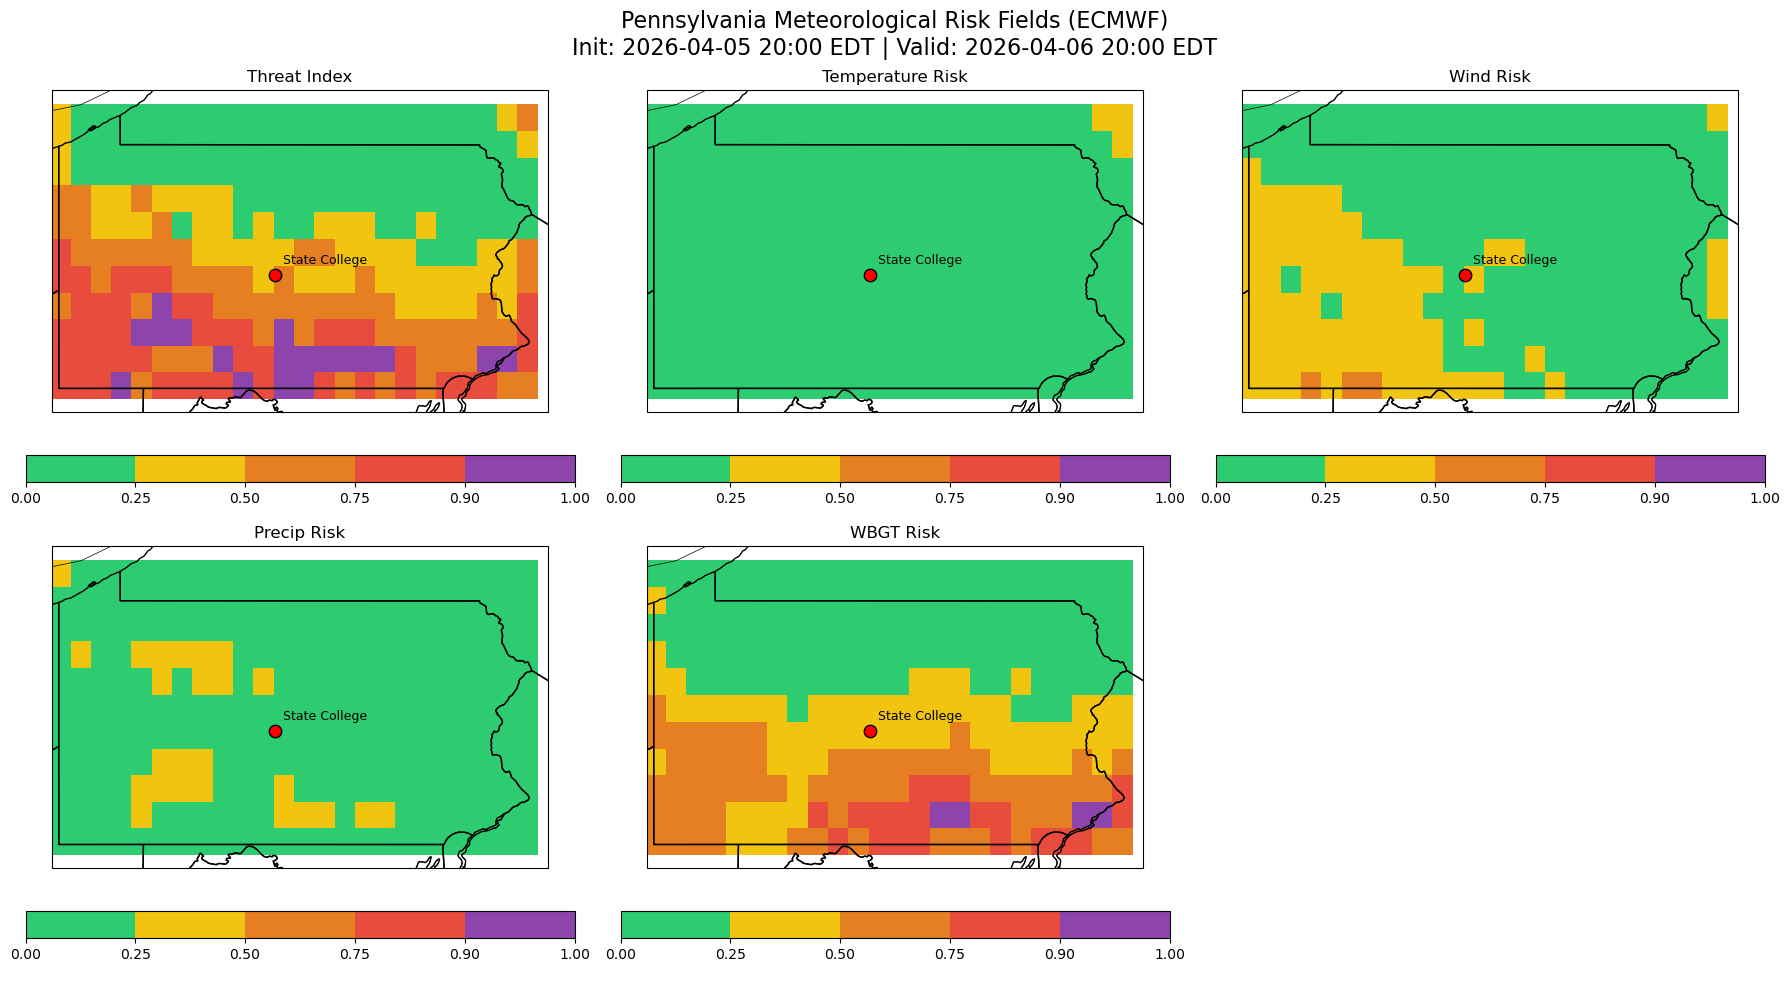

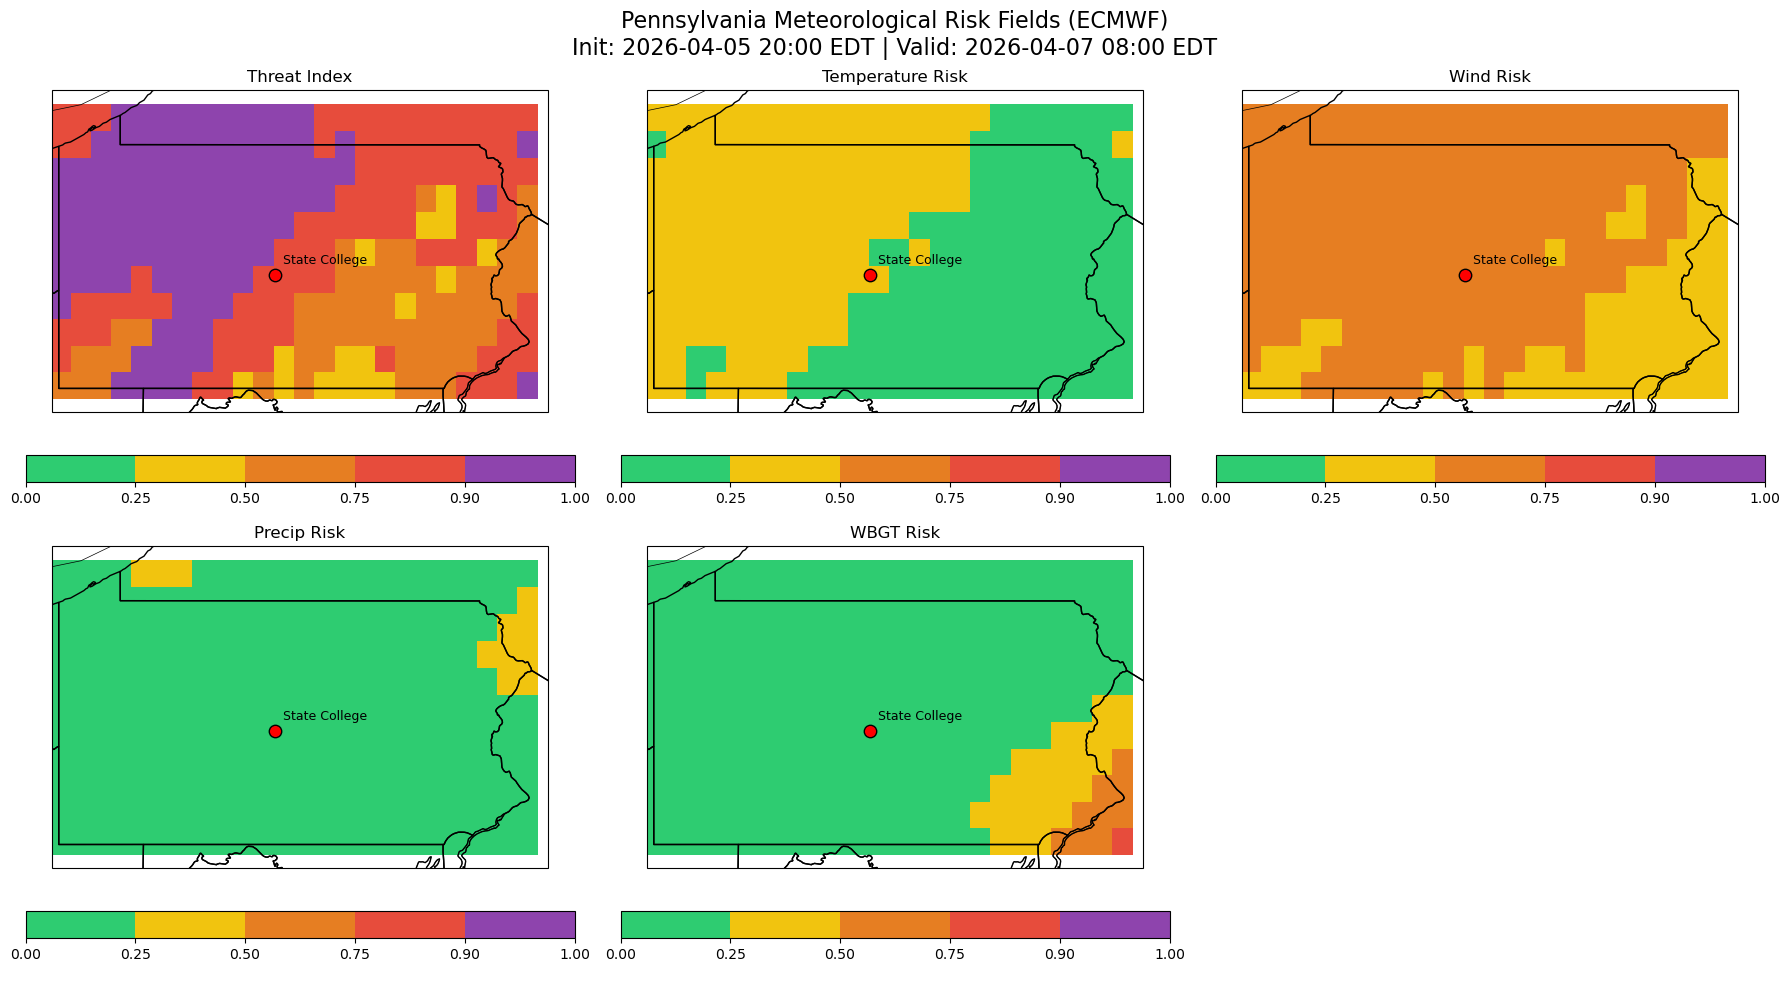

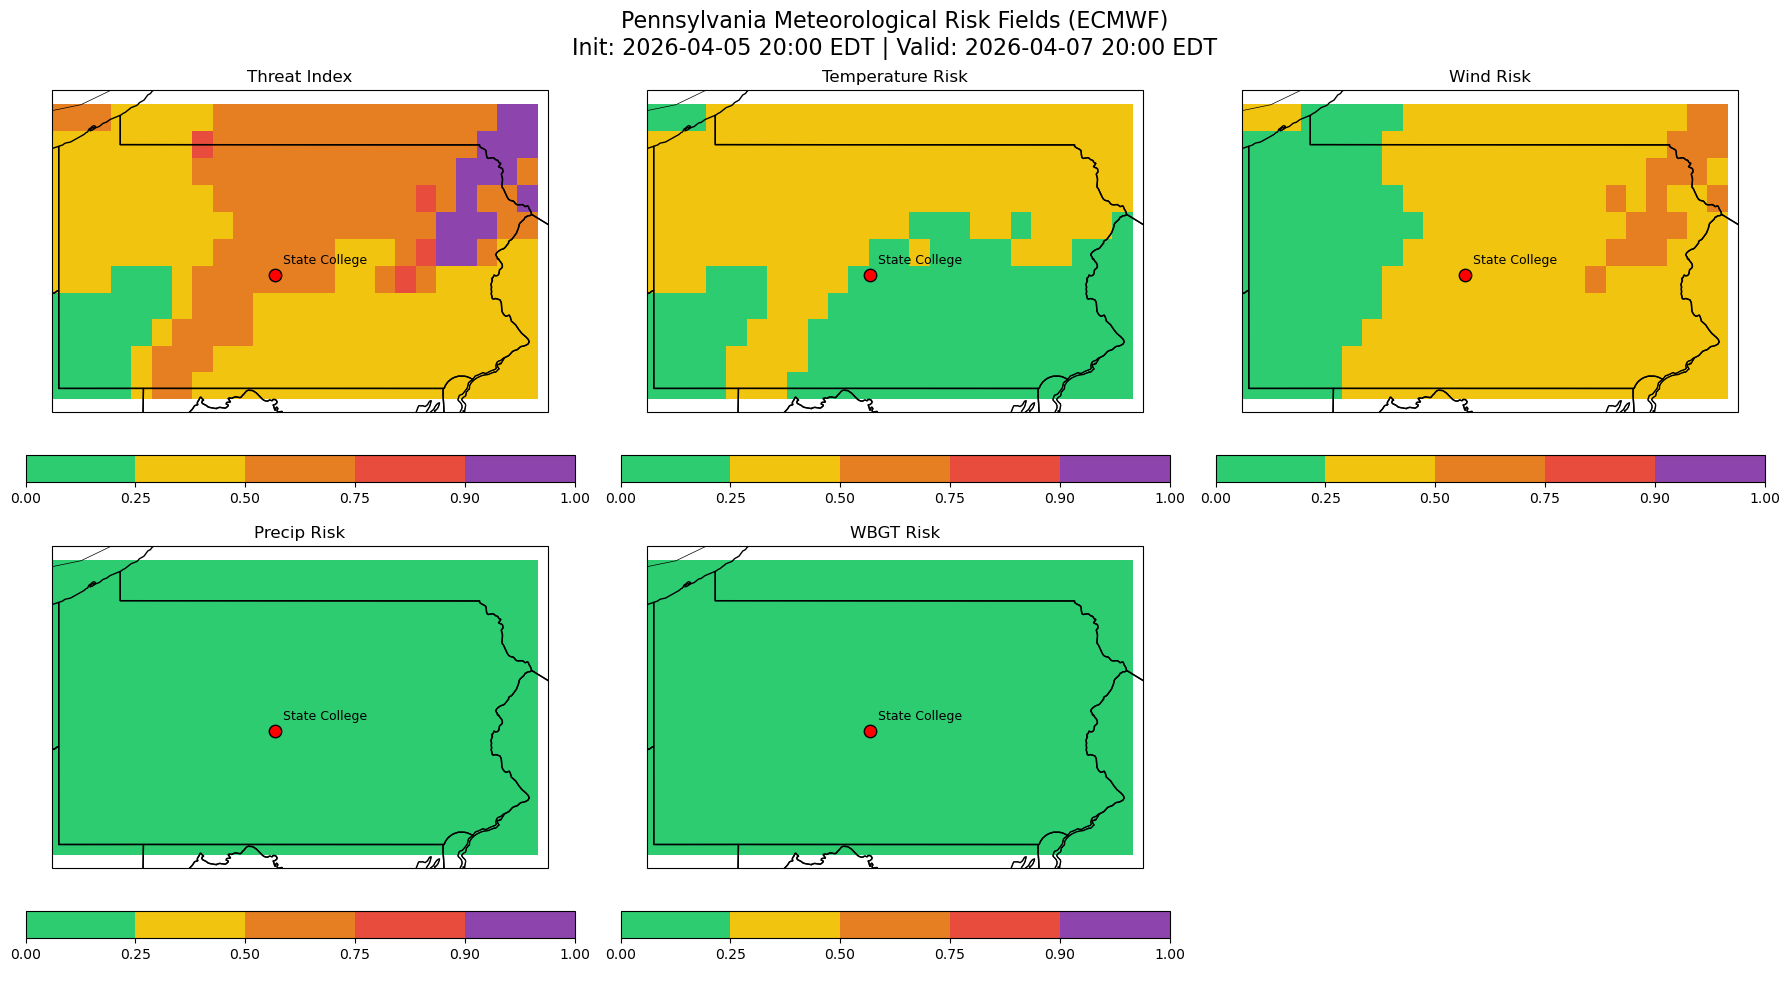

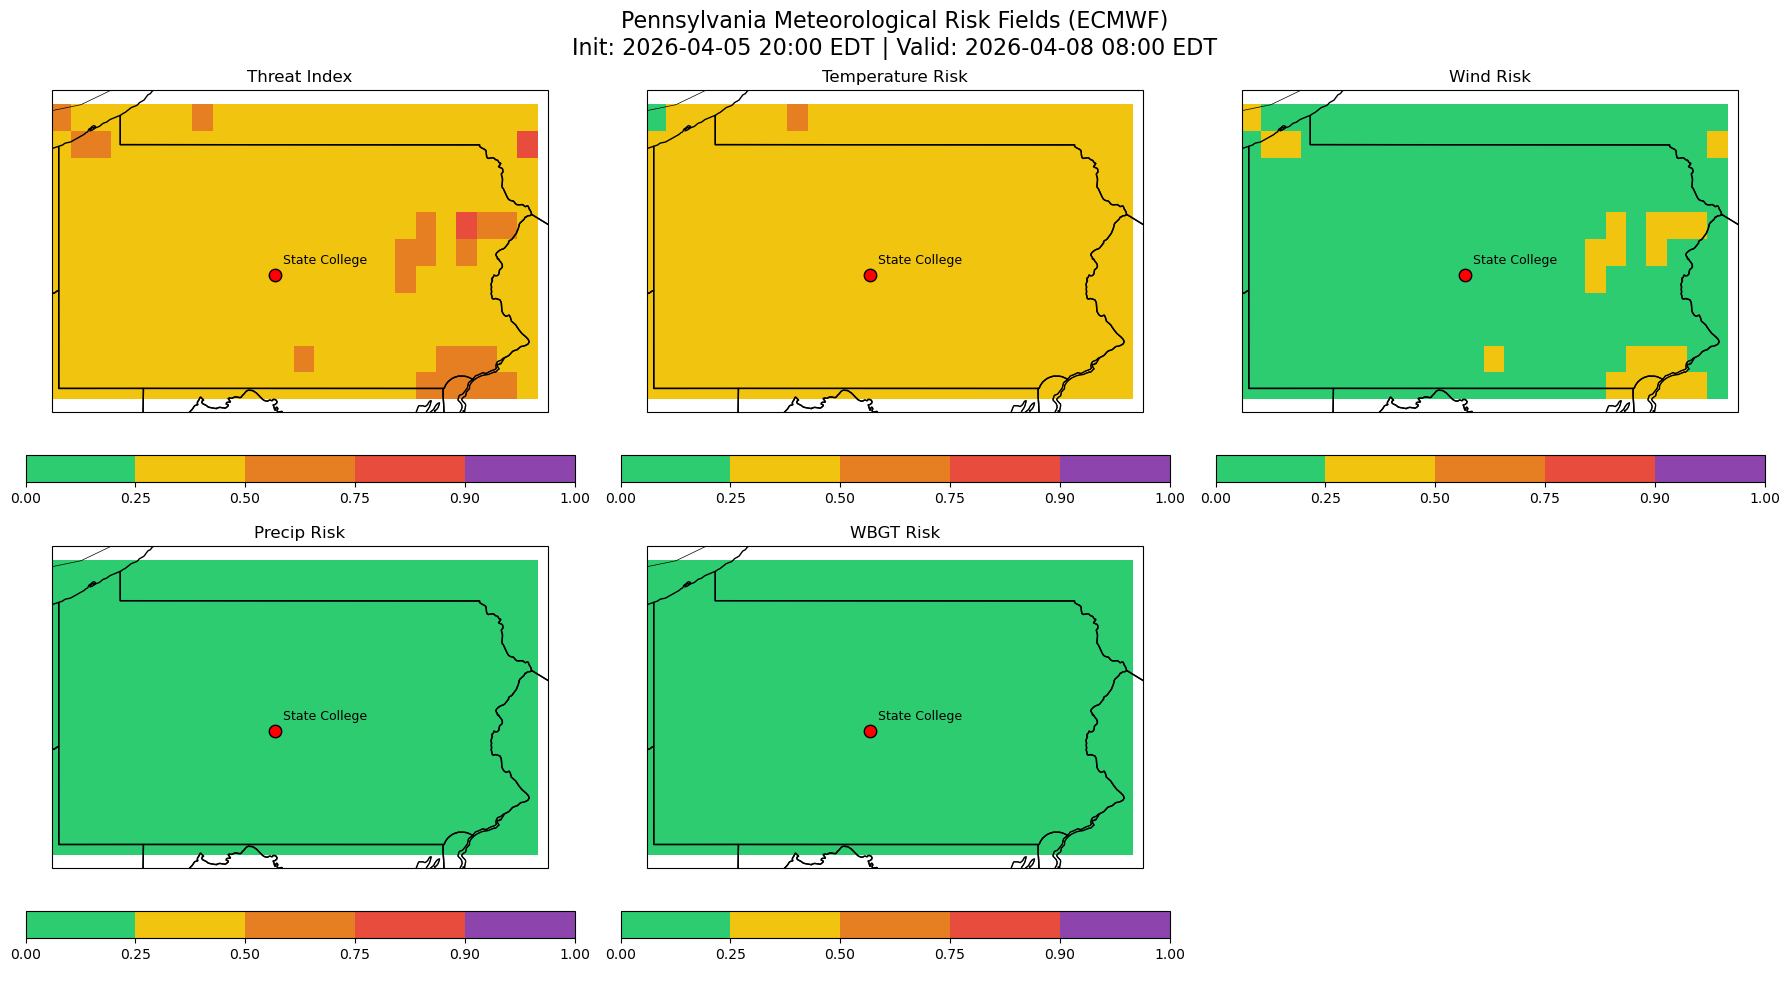

In [27]:
# ==============================
# SELECT TIME STEPS
# ==============================
times_idx = [0, 2, 4, 6, 8, 10]
times_actual = ds2.valid_time.values[times_idx]

# ==============================
# STORAGE
# ==============================
PUI_list = []
temp_risk_list = []
wind_risk_list = []
precip_risk_list = []
WBGT_risk_list = []

# ==============================
# LOOP (UNCHANGED LOGIC)
# ==============================
for i in times_idx:

    tempf2d = (ds2['t2m'].isel(valid_time=i).values - 273.15)*(9/5)+32
    dewf2d = (ds2['d2m'].isel(valid_time=i).values - 273.15)*(9/5)+32
    windgust2d = ds2['fg10'].isel(valid_time=i).values * 2.2369

    if i > 0:
        accum_precip = (
            ds2['tp'].isel(valid_time=i).values -
            ds2['tp'].isel(valid_time=i-1).values
        ) * 39.37
    else:
        accum_precip = ds2['tp'].isel(valid_time=i).values * 39.37

    RH = calc_rh(tempf2d, dewf2d)
    Tw = wet_bulb_temp(tempf2d, RH)
    WBGT = (wbgt_calc(T_c, Tw, Tg)*1.8)+32

    # --- Temperature Risk ---
    temp_risk = np.zeros_like(tempf2d)
    temp_risk[tempf2d < 40] = (40 - tempf2d[tempf2d < 40]) / 40
    mask = (tempf2d >= 40) & (tempf2d <= 75)
    temp_risk[mask] = 0
    mask = tempf2d > 75
    temp_risk[mask] = (tempf2d[mask] - 75) / 25
    temp_risk = np.clip(temp_risk, 0, 1)

    # --- WBGT Risk ---
    WBGT_risk = np.zeros_like(WBGT)
    WBGT_risk[(WBGT >= 80) & (WBGT < 85)] = 0.25
    WBGT_risk[(WBGT >= 85) & (WBGT < 88)] = 0.5
    WBGT_risk[(WBGT >= 88) & (WBGT < 90)] = 0.75
    WBGT_risk[WBGT >= 90] = 1.0

    # --- Wind Risk ---
    wind_risk = np.zeros_like(windgust2d)
    wind_risk[(windgust2d >= 15) & (windgust2d < 25)] = 0.3
    wind_risk[(windgust2d >= 25) & (windgust2d < 40)] = 0.6
    wind_risk[windgust2d >= 40] = 1.0

    # --- Precip Risk ---
    precip_risk = np.zeros_like(accum_precip)
    precip_risk[(accum_precip >= 0.05) & (accum_precip < 0.25)] = 0.3
    precip_risk[(accum_precip >= 0.25) & (accum_precip < 0.75)] = 0.6
    precip_risk[accum_precip >= 0.75] = 1.0

    temp_risk = np.nan_to_num(temp_risk)
    wind_risk = np.nan_to_num(wind_risk)
    precip_risk = np.nan_to_num(precip_risk)

    PUI = temp_risk + wind_risk + precip_risk + WBGT_risk
    PUI = np.nan_to_num(PUI)

    PUI_list.append(PUI)
    temp_risk_list.append(temp_risk)
    wind_risk_list.append(wind_risk)
    precip_risk_list.append(precip_risk)
    WBGT_risk_list.append(WBGT_risk)

# ==============================
# MAP FORMAT FUNCTION
# ==============================
def format_map(ax):
    ax.set_extent([-80.6, -74.5, 39.5, 42.5])
    ax.add_feature(cfeature.STATES, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)

    # --- State College dot ---
    ax.scatter(
        sc_lon, sc_lat,
        color='red',
        s=80,
        edgecolor='black',
        transform=ccrs.PlateCarree(),
        zorder=10
    )

    ax.text(
        sc_lon + 0.1, sc_lat + 0.1,
        "State College",
        fontsize=9,
        transform=ccrs.PlateCarree()
    )

# ==============================
# PLOTTING (NOW GEOGRAPHIC)
# ==============================
for t_idx, i in enumerate(times_idx):

    valid_time = str(times_actual[t_idx])[:16]

    fig, axs = plt.subplots(
        2, 3, figsize=(18,10),
        subplot_kw={'projection': ccrs.Mercator()}
    )

    axs = axs.flatten()

    im0 = axs[0].pcolormesh(lon2d, lat2d, PUI_list[t_idx],
                           cmap=risk_cmap, norm=norm,
                           transform=ccrs.PlateCarree())
    axs[0].set_title("Threat Index")
    format_map(axs[0])
    plt.colorbar(im0, ax=axs[0], orientation='horizontal', pad=0.1)

    im1 = axs[1].pcolormesh(lon2d, lat2d, temp_risk_list[t_idx],
                           cmap=risk_cmap, norm=norm,
                           transform=ccrs.PlateCarree())
    axs[1].set_title("Temperature Risk")
    format_map(axs[1])
    plt.colorbar(im1, ax=axs[1], orientation='horizontal', pad=0.1)

    im2 = axs[2].pcolormesh(lon2d, lat2d, wind_risk_list[t_idx],
                           cmap=risk_cmap, norm=norm,
                           transform=ccrs.PlateCarree())
    axs[2].set_title("Wind Risk")
    format_map(axs[2])
    plt.colorbar(im2, ax=axs[2], orientation='horizontal', pad=0.1)

    im3 = axs[3].pcolormesh(lon2d, lat2d, precip_risk_list[t_idx],
                           cmap=risk_cmap, norm=norm,
                           transform=ccrs.PlateCarree())
    axs[3].set_title("Precip Risk")
    format_map(axs[3])
    plt.colorbar(im3, ax=axs[3], orientation='horizontal', pad=0.1)

    im4 = axs[4].pcolormesh(lon2d, lat2d, WBGT_risk_list[t_idx],
                           cmap=risk_cmap, norm=norm,
                           transform=ccrs.PlateCarree())
    axs[4].set_title("WBGT Risk")
    format_map(axs[4])
    plt.colorbar(im4, ax=axs[4], orientation='horizontal', pad=0.1)

    axs[5].axis('off')

    init_time = pd.to_datetime(ds2['time'].values).tz_localize('UTC').tz_convert('US/Eastern')
    valid_time_et = pd.to_datetime(valid_time).tz_localize('UTC').tz_convert('US/Eastern')

    fig.suptitle(
    f"Pennsylvania Meteorological Risk Fields (ECMWF)\n"
    f"Init: {init_time.strftime('%Y-%m-%d %H:%M %Z')} | "
    f"Valid: {valid_time_et.strftime('%Y-%m-%d %H:%M %Z')}",
    fontsize=16
    )
    filename = f"April_{i:03d}.png"
    plt.savefig(filename, dpi=100, bbox_inches="tight")

    plt.tight_layout()
    plt.show()



# Algorithm Performance
## 1. Did it produce reasonable values?

Yes, the algorithm produces reasonable and intuitive values for an outdoor sports safety index.

Logical Scaling: By normalizing each component (Temperature, Wind, Precipitation, and WBGT) to a scale of 0 to 1 before summing them, the "Threat Index" (PUI) effectively highlights days where single variables are extreme (e.g., wind gusts over 40 mph) or where multiple moderate hazards overlap (e.g., a cold, rainy, and windy day).

Meteorological Consistency: The temperature formula correctly identifies risk at both extremes (below 40F and above 75F), which aligns with human health concerns like hypothermia and heat exhaustion.

Cumulative Impact: The additive nature of the formula ensures that a day with "moderate" rain and "moderate" wind yields a higher threat level than a day with only one of those factors, which is a realistic representation of safety for IM sports.

## 2. Were there false alarms or missed threats?

Potential False Alarms: The threshold for Wind Risk starts at 15 mph (triggering a 0.3 risk). In a wind-prone state like Pennsylvania, 15 mph gusts are common and might not always warrant a "yellow" caution for sports like soccer or football. This could lead to frequent low-level warnings that officials might eventually ignore (warning fatigue).

Potential Missed Threats: The algorithm relies heavily on accumulated precipitation (tp) to gauge rain risk. However, for outdoor sports safety, lightning is a primary threat that can occur even with very low total precipitation. Since lightning is not explicitly weighted or detected in this specific model iteration, a fast-moving, low-precipitation thunderstorm could be "missed" or undervalued by the PUI.

## 3. Did you need to revise the formula? If so, how?

While a threshold system was always in place, the formula required reweighting to better distinguish between different atmospheric regimes:

Amplifying the Contrast: The weights were adjusted to create a sharper mathematical "gap" between a "perfect day" and a "storm day." In earlier tests, a calm, clear day was returning a baseline value that felt too close to a marginal weather day. By widening the distance between the zero-risk safety window (40F–75F) and the high-risk tiers, the index now provides much clearer "Clear/No-Go" signals for campus officials.

Tiered Intensity: We shifted the internal weight of high-impact events (like wind gusts over 40 mph or heavy rain) to ensure they could trigger a high threat index independently, rather than needing multiple variables to reach a "cancellation" level.

In [20]:
#calling variables for threat index run
ds_a = xr.open_dataset("Marecmwf_20260323Mar.nc")
ds_b = xr.open_dataset("10fgMarecmwf_20260323Mar.nc")
ds2 = xr.merge([ds_a, ds_b], compat = 'override')
ds2

sh: 1: getfattr: not found
sh: 1: getfattr: not found


<xarray.Dataset> Size: 80kB
Dimensions:            (valid_time: 15, latitude: 11, longitude: 24)
Coordinates:
  * valid_time         (valid_time) datetime64[ns] 120B 2026-03-23 ... 2026-0...
  * latitude           (latitude) float64 88B 42.25 42.0 41.75 ... 40.0 39.75
  * longitude          (longitude) float64 192B -80.5 -80.25 ... -75.0 -74.75
    time               datetime64[ns] 8B ...
    step               (valid_time) timedelta64[ns] 120B ...
    surface            float64 8B ...
    heightAboveGround  float64 8B ...
Data variables:
    tp                 (valid_time, latitude, longitude) float32 16kB ...
    sf                 (valid_time, latitude, longitude) float32 16kB ...
    t2m                (valid_time, latitude, longitude) float32 16kB ...
    d2m                (valid_time, latitude, longitude) float32 16kB ...
    fg10               (valid_time, latitude, longitude) float32 16kB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-04-08T17:28 GRIB to CDM+CF via cfgrib-0.9.1...

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap, BoundaryNorm

In [22]:
# ==============================
# TIME STEPS
# ==============================
times_idx = list(range(0, 14, 1))
times_actual = ds2.valid_time.values[times_idx]

# ==============================
# STORAGE
# ==============================
PUI_list = []
temp_risk_list = []
wind_risk_list = []
precip_risk_list = []
WBGT_risk_list = []

In [23]:
# ==============================
# LOOP (UNCHANGED PHYSICS)
# ==============================
for i in times_idx:

    tempf2d = (ds2['t2m'].isel(valid_time=i).values - 273.15)*(9/5)+32
    dewf2d = (ds2['d2m'].isel(valid_time=i).values - 273.15)*(9/5)+32
    windgust2d = ds2['fg10'].isel(valid_time=i).values * 2.2369

    if i > 0:
        accum_precip = (
            ds2['tp'].isel(valid_time=i).values -
            ds2['tp'].isel(valid_time=i-1).values
        ) * 39.37
    else:
        accum_precip = ds2['tp'].isel(valid_time=i).values * 39.37

    RH = calc_rh(tempf2d, dewf2d)
    Tw = wet_bulb_temp(tempf2d, RH)
    WBGT = (wbgt_calc(T_c, Tw, Tg)*1.8)+32

    # --- Temperature Risk ---
    temp_risk = np.zeros_like(tempf2d)
    temp_risk[tempf2d < 40] = (40 - tempf2d[tempf2d < 40]) / 40
    mask = (tempf2d >= 40) & (tempf2d <= 75)
    temp_risk[mask] = 0
    mask = tempf2d > 75
    temp_risk[mask] = (tempf2d[mask] - 75) / 25
    temp_risk = np.clip(temp_risk, 0, 1)

    # --- WBGT Risk ---
    WBGT_risk = np.zeros_like(WBGT)
    WBGT_risk[(WBGT >= 80) & (WBGT < 85)] = 0.25
    WBGT_risk[(WBGT >= 85) & (WBGT < 88)] = 0.5
    WBGT_risk[(WBGT >= 88) & (WBGT < 90)] = 0.75
    WBGT_risk[WBGT >= 90] = 1.0

    # --- Wind Risk ---
    wind_risk = np.zeros_like(windgust2d)
    wind_risk[(windgust2d >= 15) & (windgust2d < 25)] = 0.3
    wind_risk[(windgust2d >= 25) & (windgust2d < 40)] = 0.6
    wind_risk[windgust2d >= 40] = 1.0

    # --- Precip Risk ---
    precip_risk = np.zeros_like(accum_precip)
    precip_risk[(accum_precip >= 0.05) & (accum_precip < 0.25)] = 0.3
    precip_risk[(accum_precip >= 0.25) & (accum_precip < 0.75)] = 0.6
    precip_risk[accum_precip >= 0.75] = 1.0

    temp_risk = np.nan_to_num(temp_risk)
    wind_risk = np.nan_to_num(wind_risk)
    precip_risk = np.nan_to_num(precip_risk)

    PUI = temp_risk + wind_risk + precip_risk + WBGT_risk
    PUI = np.nan_to_num(PUI)

    PUI_list.append(PUI)


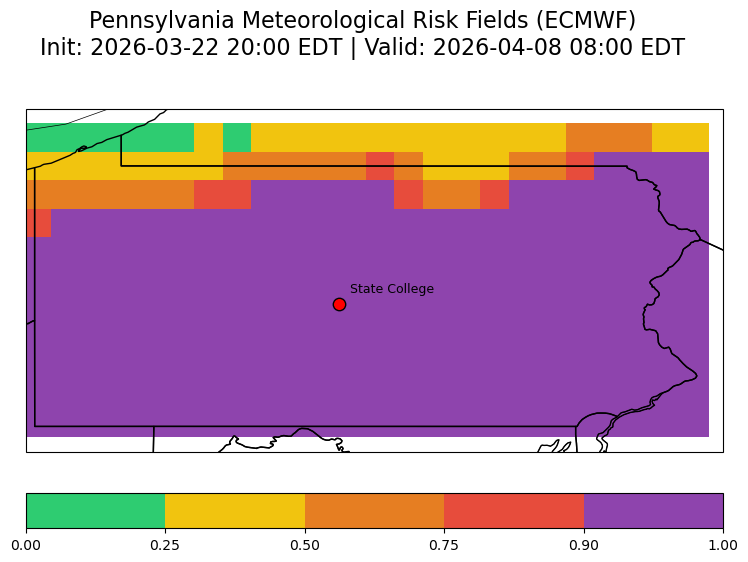

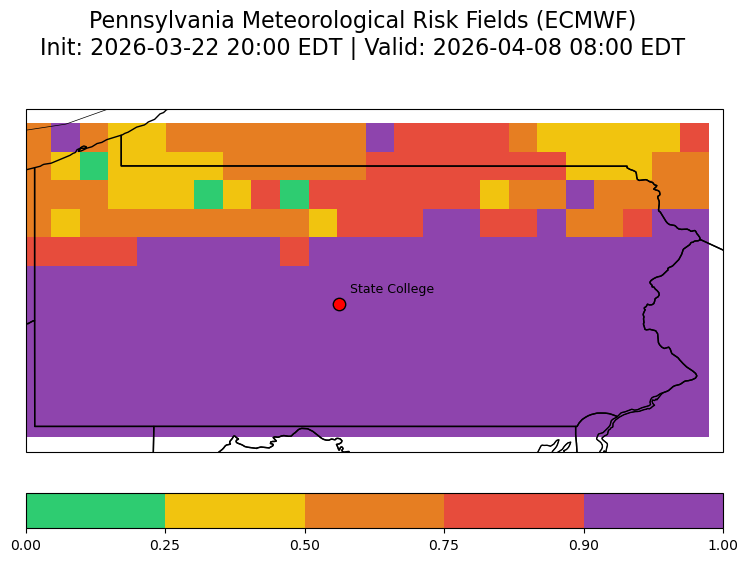

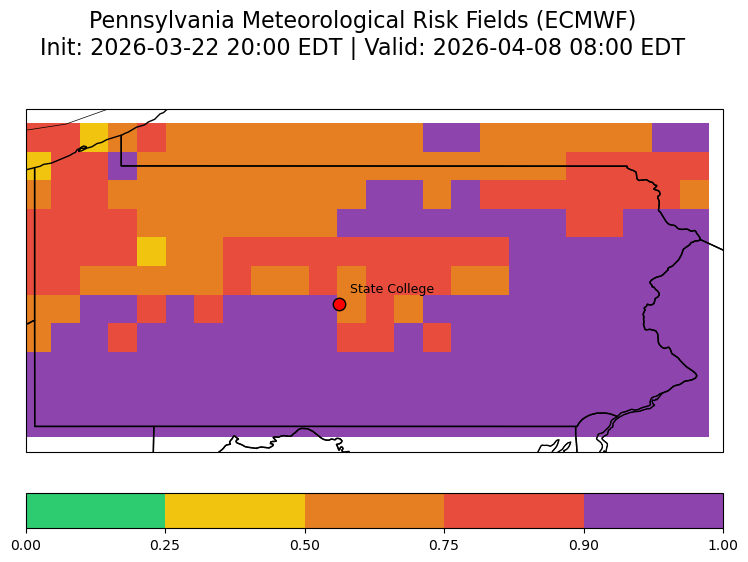

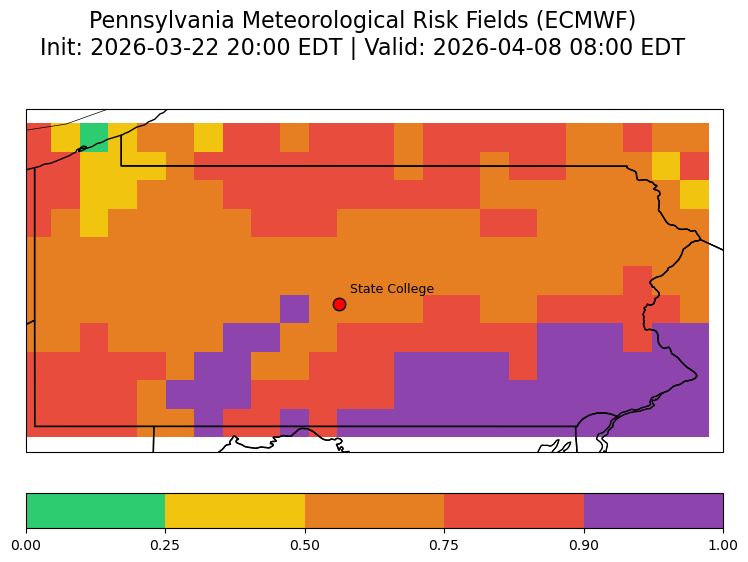

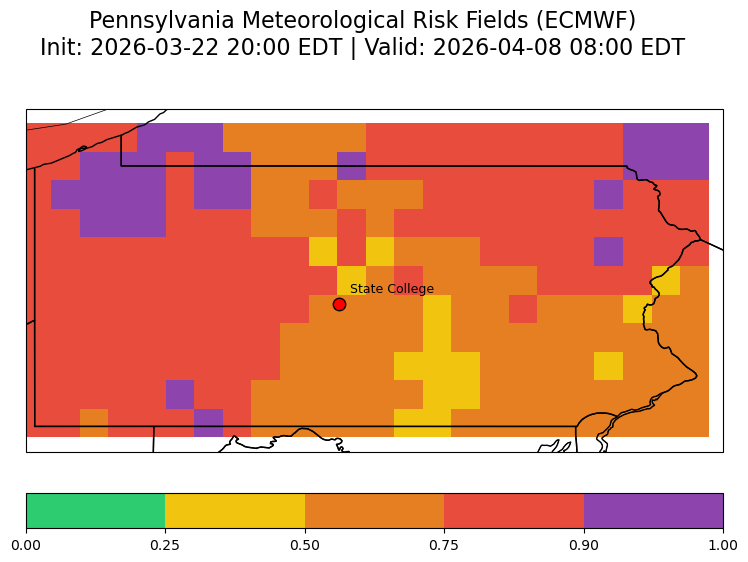

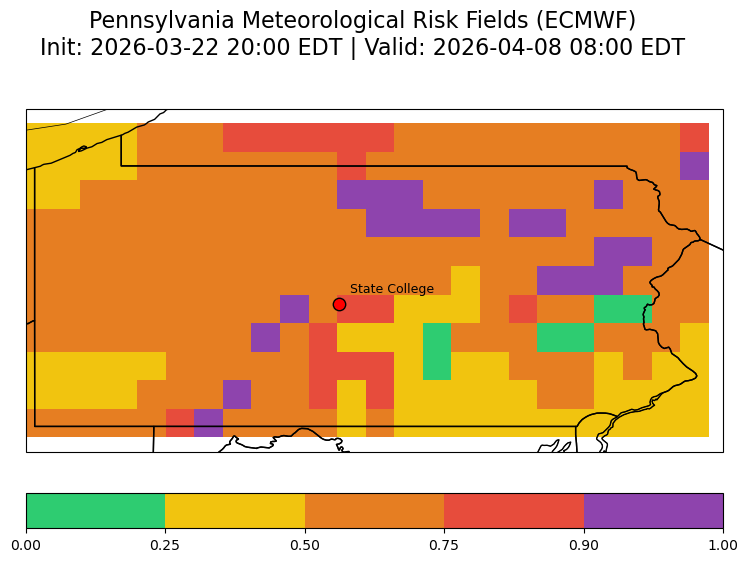

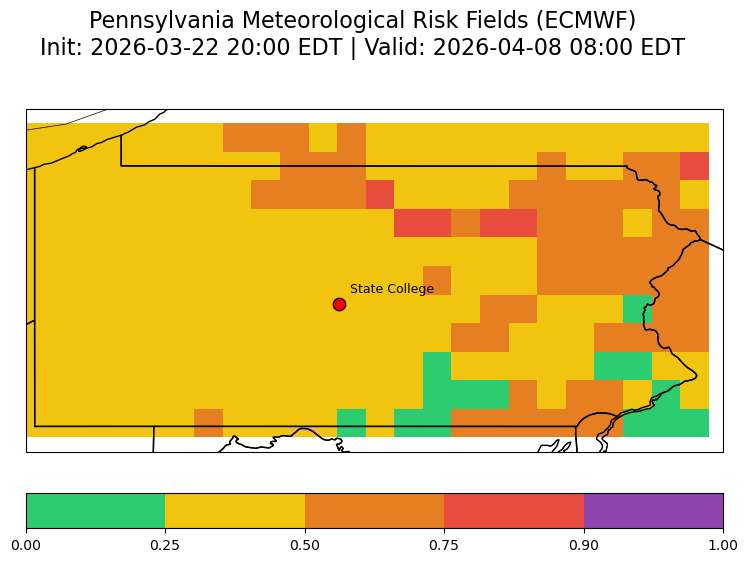

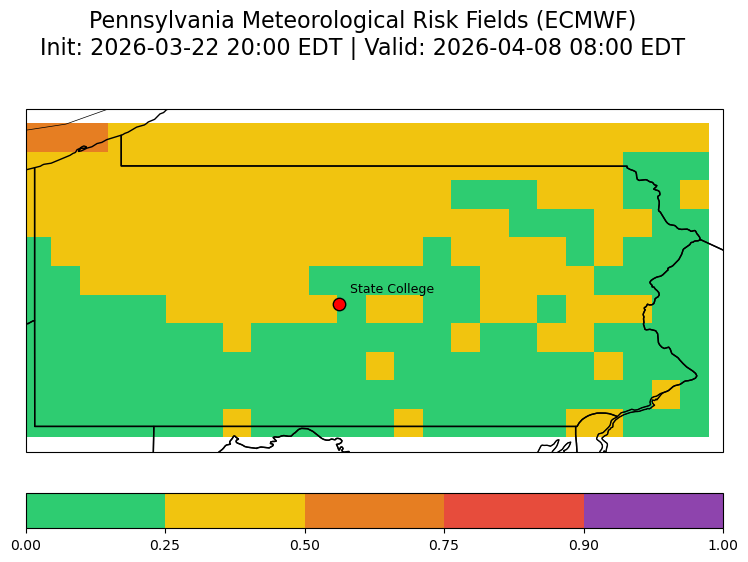

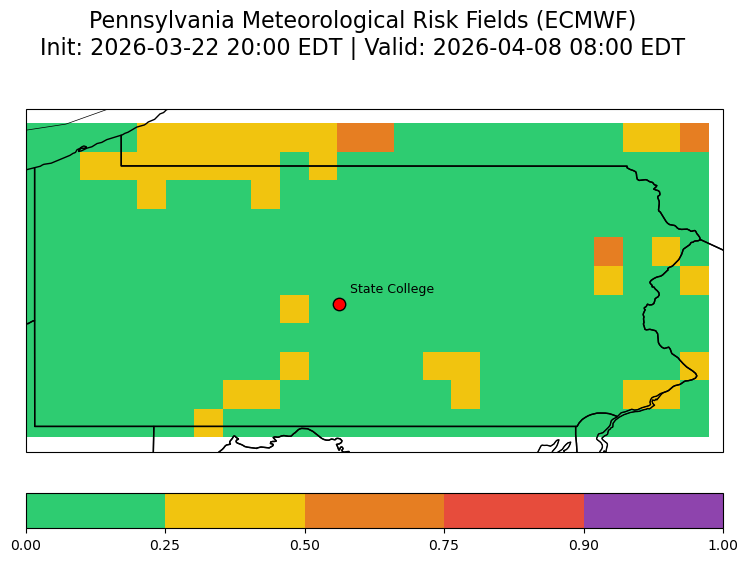

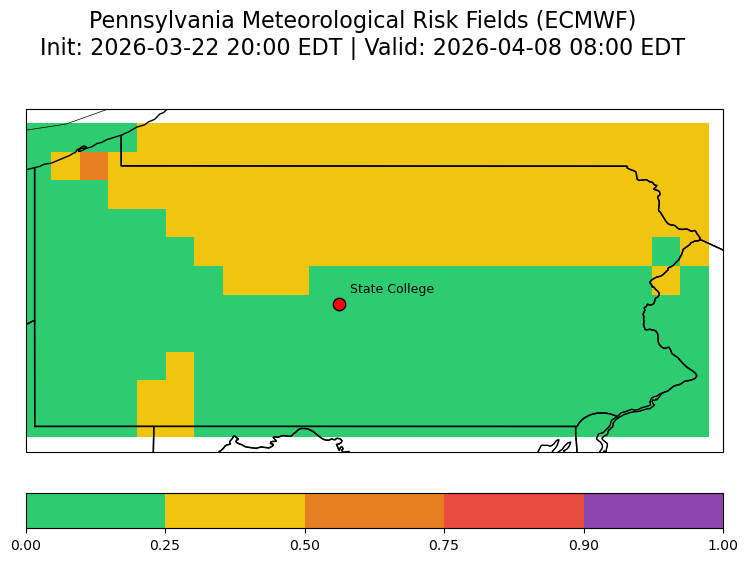

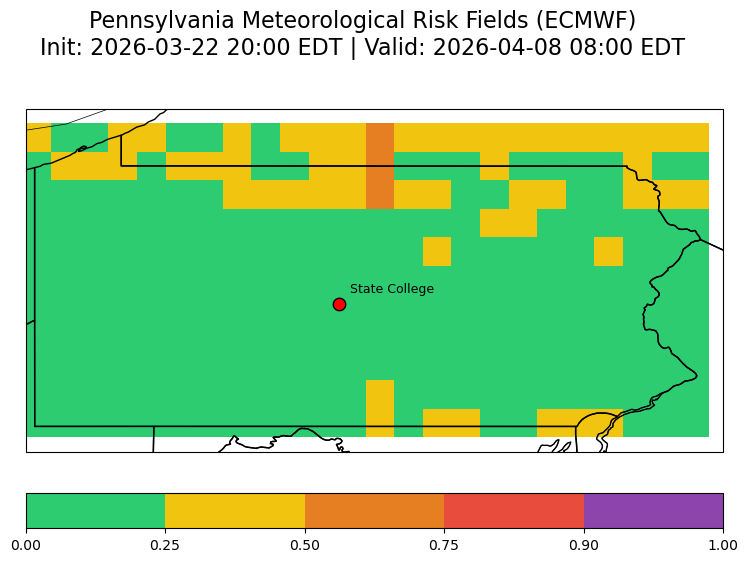

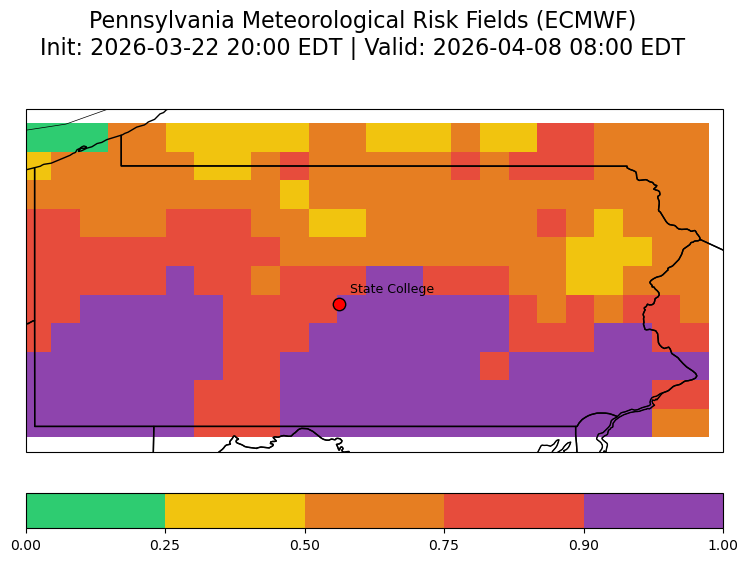

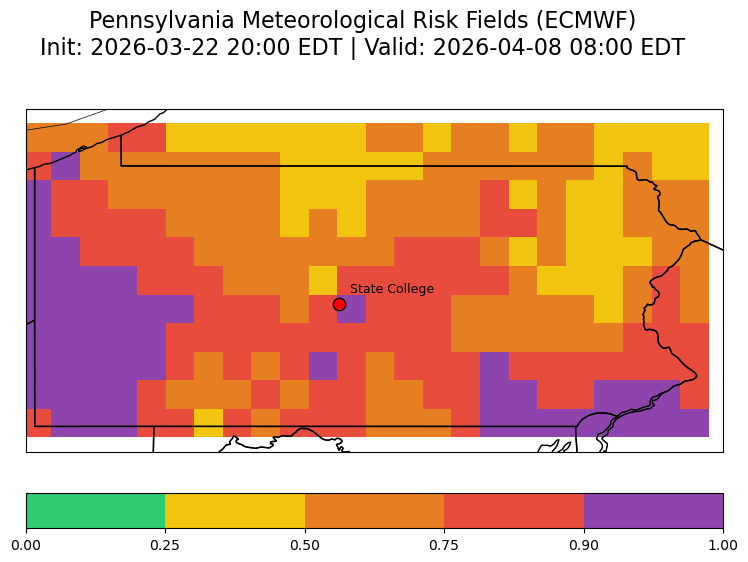

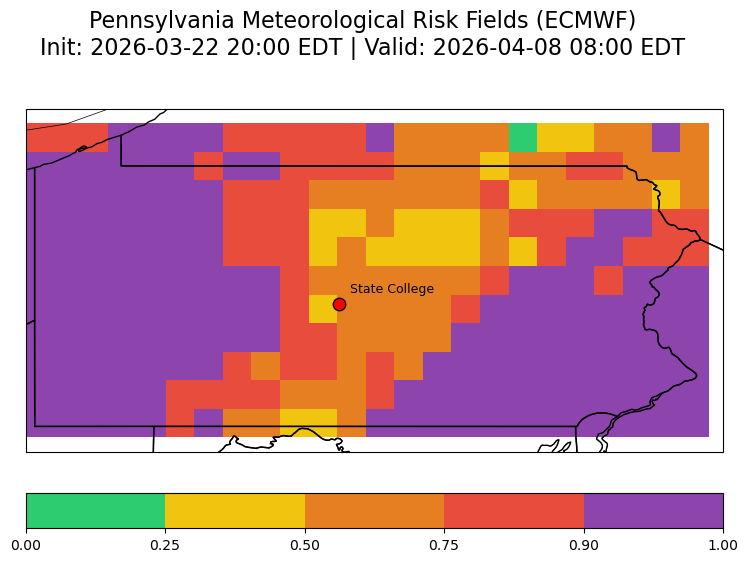

In [24]:


# ==============================
# PLOTTING OVER PA MAP
# ==============================
for i in range(0, 14):

    fig, ax = plt.subplots(
        figsize=(9,7),
        subplot_kw={'projection': ccrs.PlateCarree()}
    )
    fig.subplots_adjust(top=1.3)
    # --- MAP BASE ---
    ax.set_extent([-80.6, -74.5, 39.5, 42.5])
    ax.add_feature(cfeature.STATES, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)

    # --- PLOT FIELD ---
    im = ax.pcolormesh(
        lon2d, lat2d,
        PUI_list[i],
        cmap=risk_cmap,
        norm=norm,
        transform=ccrs.PlateCarree()
    )

    # --- STATE COLLEGE DOT ---
    ax.scatter(
        sc_lon, sc_lat,
        color='red',
        s=80,
        edgecolor='black',
        transform=ccrs.PlateCarree(),
        zorder=10
    )

    ax.text(
        sc_lon + 0.1,
        sc_lat + 0.1,
        "State College",
        fontsize=9,
        transform=ccrs.PlateCarree()
    )

    init_time = pd.to_datetime(ds2['time'].values).tz_localize('UTC').tz_convert('US/Eastern')
    valid_time_et = pd.to_datetime(valid_time).tz_localize('UTC').tz_convert('US/Eastern')

    fig.suptitle(
    f"Pennsylvania Meteorological Risk Fields (ECMWF)\n"
    f"Init: {init_time.strftime('%Y-%m-%d %H:%M %Z')} | "
    f"Valid: {valid_time_et.strftime('%Y-%m-%d %H:%M %Z')}",
    fontsize=16
    )

    

    # --- COLORBAR ---
    plt.colorbar(im, ax=ax, shrink=1,orientation='horizontal', pad=0.05)

    # ==============================
    # SAVE FIGURE
    # ==============================
    filename = f"pa_threat_maps/threat_{i:03d}.png"
    plt.savefig(filename, dpi=100, bbox_inches="tight")

    #plt.show()
    #plt.close()